## Generative Adversarial Network

Generative Adversarial Networks a.k.a GANs, are popular generative neural networks. GANs have demonstrated their effectiveness in nearly every problem in computer vision. The GAN works by training a pair of networks, Generator and Discriminator, with competing loss terms. As an analogy, we can think of these networks as an art-forger and the other, an art-expert. In GAN literature the Generator is the art-forger and the Discriminator is the art-expert. The Generator is trained to produce fake images (forgeries) to deceive the art-expert (Discriminator). The Discriminator which receives both the real images and fake images tries to distinguish between them to identify the fake images. The Generator uses the feedback from the Discriminator to improve it generation. Both the models are trained simulataneously and are always in competition with each other. This competition between the Generator and Discriminator drives them to improve their respective models continuously. The  model converges when the Generator produces fake images that are indistinguishable from the real images.  <br>

In this setup, the Generator does not have access to the real images whereas the Discriminator has access to both the real and the generated fake images. 

Let us define Discriminator D that takes an image as input and produces a number **(0/1)** as output and a Generator G that takes random noise as input and outputs a fake image. In practice, G and D are trained alternately i.e., For a fixed generator G, the Discriminator D is trained to classify the training data as real (output a value close to 1) or fake(output a value close to 0). Subsequenty, we freeze the Discriminator and train the Generator G to produce an image (fake) that outputs a value close to 1 (real) when passed through the Discriminator D. Thus, if the Generator is perfectly trained then the Discriminator D will be maximally confused by the images generated by G and predict 0.5 for all the inputs. 

In this assignment, we will implement a Generative Adversarial Network on MNIST data and generate images that resemble the digits from the MNIST dataset.

To implement a GAN, we basically require 5 components:

- Real Dataset (real distribution)
- Low dimensional random noise that is input to the Generator to produce fake images
- Generator that generates fake images
- Discriminator that acts as an expert to distinguish real and fake images.
- Training loop where the competition occurs and models better themselves.


Let us implement each of the parts and train the overall model:

In [1]:
## import packages
import torch
import random
import numpy as np
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torchvision.datasets as dset
import os
import numpy.testing as npt
from torchsummary import summary

import matplotlib.pyplot as plt
'exec(%matplotlib inline)'
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

## Checks for the availability of GPU 
is_cuda = torch.cuda.is_available()
if is_cuda:
    print("working on gpu!")
else:
    print("No gpu! only cpu ;)")
    
## The following random seeds are just for deterministic behaviour of the code and evaluation

##############################################################################
################### DO NOT MODIFY THE CODE BELOW #############################    
##############################################################################

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = '0'

############################################################################### 

working on gpu!


### Download Data and Setup DataLoader

In this step we work on preparing the data. We normalize the images to range [-1, +1] 

In [2]:
import torchvision
import torchvision.transforms as transforms
import os

if not os.path.isdir('/userdata/zylabfiles'):
    os.mkdir('/userdata/zylabfiles')
if not os.path.isdir('/userdata/zylabfiles/data'):
    os.mkdir('/userdata/zylabfiles/data')
root = '/userdata/zylabfiles/data'

train_bs = 128

# Data transformation for the DataLoader - normalizes to between [-1,1]
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.5], std=[0.5])])

training_data = torchvision.datasets.MNIST(root, train=True, transform=transform,download=True)
train_loader = torch.utils.data.DataLoader(dataset=training_data, batch_size=train_bs, shuffle=True, drop_last=True)

### Noise Input for the Generator 

Let us define a function which takes (batchsize, dimension) as input and returns a random noise of requested dimensions. This noise tensor will be the input to the generator.

In [3]:
def noise(bs, dim):
    """Generate random Gaussian noise vectors N(0,I), with mean 0 and variance 1.
    
    Inputs:
    - bs: integer giving the batch size of noise to generate.
    - dim: integer giving the dimension of the Gaussain noise to generate.
    
    Returns:
    A PyTorch Tensor containing Gaussian noise with shape [bs, dim]
    """
    
    out = (torch.randn((bs, dim)))
    if is_cuda:
        out = out.cuda()
    return out

### Generator Architecture - 20 points

Define a Generator with the following architecture. 

- Linear layer (noise_dim -> 256)
- LeakyReLU (works well for the Generators, we will use negative_slope=2)
- Linear Layer (256 -> 512)
- LeakyReLU
- Linear Layer (512 -> 1024)
- LeakyReLU
- Linear Layer (1024 -> 784) (784 is the MNIST image size 28*28)
- TanH (To scale the generated images to [-1,1], the same as real images)

- LeakyRELU: https://pytorch.org/docs/stable/nn.html#leakyrelu 
- Fully connected layer: https://pytorch.org/docs/stable/nn.html#linear 
- TanH activation: https://pytorch.org/docs/stable/nn.html#tanh

In [4]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100, out_size=784):
        super(Generator, self).__init__()
        
        '''
        REST OF THE MODEL HERE
        
        # define a fully connected layer (self.layer1) from noise_dim -> 256 neurons      
        # define a leaky relu layer(self.leaky_relu) with negative slope=0.2. We can reuse the same layer multiple times.
        # define a fully connected layer (self.layer2) from 256 -> 512 neurons
        # define a fully connected layer (self.layer3) from 512 -> 1024 neurons
        # define a fully connected layer (self.layer4) from 1024 -> out_size neurons
        # define a tanh activation function (self.tanh)
        
        '''
        # your code here
        self.layer1 = nn.Linear(noise_dim, 256)
        self.leaky_relu = nn.LeakyReLU(0.2,inplace=False)
        self.layer2= nn.Linear(256, 512)
        self.layer3 = nn.Linear(512, 1024)
        self.layer4 = nn.Linear(1024, out_size)
        self.tanh = nn.Tanh()
        
        
    def forward(self, x):
        '''
        Make a forward pass of the input through the generator. Leaky relu is used as the activation 
        function in all the intermediate layers. Tanh activation function is only used at the end (which
        is after self.layer4)
        
        Note that, generator takes an random noise as input and gives out fake "images". Hence, the Tensor 
        output after tanh activation function should be reshaped into the same size as the real images. i.e., 
        [batch_size, n_channels, H, W] == (batch_size, 1,28,28). You may use the .view(.) function to acheive it.
         
        '''
         # your code here
        batch_size= x.shape[0]
        x = self.layer1(x)
        x = self.leaky_relu(x)
        x = self.layer2(x)
        x = self.leaky_relu(x)
        x = self.layer3(x)
        x = self.leaky_relu(x)
        x = self.layer4(x)
        x = self.tanh(x)
        
        return x.view(batch_size,1,28,28)
             

In [5]:
# Initialize the Generator and move it to GPU (if is_cuda)
generator = Generator()
print(generator)
# If you have a system with a GPU, you may want to install torchsummary and display the network in more detail 
summary(generator,(100,), device='cpu')

# move to GPU
if is_cuda:
    generator = generator.cuda()

Generator(
  (layer1): Linear(in_features=100, out_features=256, bias=True)
  (leaky_relu): LeakyReLU(negative_slope=0.2)
  (layer2): Linear(in_features=256, out_features=512, bias=True)
  (layer3): Linear(in_features=512, out_features=1024, bias=True)
  (layer4): Linear(in_features=1024, out_features=784, bias=True)
  (tanh): Tanh()
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]          25,856
         LeakyReLU-2                  [-1, 256]               0
            Linear-3                  [-1, 512]         131,584
         LeakyReLU-4                  [-1, 512]               0
            Linear-5                 [-1, 1024]         525,312
         LeakyReLU-6                 [-1, 1024]               0
            Linear-7                  [-1, 784]         803,600
              Tanh-8                  [-1, 784]               0
Total params: 1,486,3

In [6]:
# Test cases
# Note the testcases only tests for input and output dimensions and range of values. 
# You may modify the architecture within those constraints
# noise_dim is always 100
# Input to generator is (B,noise_dim) where B is arbitray batch_size
# Output of the Generator is (B,1,28,28) where B is arbitray batch_size, 1 is the grayscale channel 28 is image size 
# The Generator Output is between [-1,1] since we use tanh() activations. 
# Input to Discriminator is (B,1,28,28), where B is arbitray batch_size, 1 is the grayscale channel 28 is image size
# output of the discriminator is Tensor of dimension (B,1) where B is arbitray batch_size 

a = torch.ones(5,100)
if is_cuda:
    a = a.cuda()
out = generator(a)
npt.assert_equal(out.shape, (5,1,28,28))
assert np.max(out.detach().cpu().numpy()) <= 1
assert np.min(out.detach().cpu().numpy()) >= -1

### Discriminator Architecture - 20 points

Define a Discriminator with the following architecture. 

- Linear Layer (input_size -> 512)
- LeakyReLU with negative slope = 0.2
- Linear Layer (512 -> 256)
- LeakyReLU with negative slope = 0.2
- Linear Layer (256 -> 1)

In [7]:
## Similar to the Generator, we now define a Discriminator which takes in a vector and output a single scalar 
## value. 

class Discriminator(nn.Module):
    def __init__(self, input_size=784):
        super(Discriminator, self).__init__()
        '''
        REST OF THE MODEL HERE
        
        # define a fully connected layer (self.layer1) from input_size -> 512 neurons   
        # define a leaky relu layer(self.leaky_relu) with negative slope=0.2. (we will reuse the same layer)
        # define a fully connected layer (self.layer2) from 512 -> 256 neurons
        # define a fully connected layer (self.layer3) from 256 -> 1 neurons
        '''
        # your code here
        self.layer1 = nn.Linear(input_size, 512)
        self.leaky_relu = nn.LeakyReLU(0.2,inplace=False)
        self.layer2 = nn.Linear(512, 256)
        self.layer3 = nn.Linear(256, 1)
    
    def forward(self, x):
        '''
        The Discriminator takes a vectorized input of the real and generated fake images. Reshape the input 
        to match the Discriminator architecture. 
        
        Make a forward pass of the input through the Discriminator and return the scalar output of the 
        Discriminator.
        '''
        # your code here
        flattened_x = x.view(x.size(0), -1)
        x = self.layer1(flattened_x)
        x = self.leaky_relu(x)
        x = self.layer2(x)
        x = self.leaky_relu(x)
        x = self.layer3(x)
        
        return x       
        

In [8]:
# Initialize the Discriminator and move it to GPU (if is_cuda)
discriminator = Discriminator()

print(discriminator)
# If you have a system with a GPU, you may want to install torchsummary and display the network in more detail 
# summary(discriminator,(784,), device='cpu')

# move to GPU
if is_cuda:
    discriminator = discriminator.cuda()

Discriminator(
  (layer1): Linear(in_features=784, out_features=512, bias=True)
  (leaky_relu): LeakyReLU(negative_slope=0.2)
  (layer2): Linear(in_features=512, out_features=256, bias=True)
  (layer3): Linear(in_features=256, out_features=1, bias=True)
)


In [9]:
# Test cases
# Note the testcases only tests for input and output dimensions and range of values. 
# You may modify the architecture within those constraints
# noise_dim is always 100
# Input to generator is (B,noise_dim) where B is arbitray batch_size
# Output of the Generator is (B,1,28,28) where B is arbitray batch_size, 1 is the grayscale channel 28 is image size 
# The Generator Output is between [-1,1] since we use tanh() activations. 
# Input to Discriminator is (B,1,28,28), where B is arbitray batch_size, 1 is the grayscale channel 28 is image size
# output of the discriminator is Tensor of dimension (B,1) where B is arbitray batch_size 

a = torch.ones(5,1,28,28)
if is_cuda:
    a = a.cuda()
out = discriminator(a)
npt.assert_equal(out.shape, (5,1))

### Binary Cross Entropy Loss 

We will use the Binary cross entropy loss function to train the GAN. The loss function includes sigmoid activation followed by logistic loss. This allows us to distinguish between real and fake images.

Binary cross entropy loss with logits: https://pytorch.org/docs/stable/nn.html#bcewithlogitsloss

In [10]:
# Initialize the 'BCEWithLogitsLoss' object
bce_loss = nn.BCEWithLogitsLoss()

### Discriminator Loss  - 10 points

Let's define the objective function for the Discriminator. It takes as input the logits (outputs of the Discriminator) and the labels (real or fake). It uses the BCEWithLogitsLoss() to compute the loss in classification.

In [11]:
def DLoss(logits_real, logits_fake, targets_real, targets_fake):
    '''
    Returns the Binary Cross Entropy Loss between predictions and targets
    
    Inputs:
        logits_real: the outputs of the discriminator (before the sigmoid) for real images
        logits_fake: the outputs of the discriminator (before the sigmoid) for fake images
        targets_real: groundtruth labels for real images
        targets_fake: groundtruth labels for fake images
    
    '''
    # Concatenate the logits_real and the logits_fake using torch.cat() to get 'logits'
    # Concatenate the targets_real and the targets_fake using torch.cat() to get 'targets'
    # estimate the loss using the BCEWithLogitsLoss object 'bce' with 'logits' and 'targets'
    # your code here
    logits = torch.cat((logits_real,logits_fake),1)
    targets = torch.cat ((targets_real, targets_fake),1)
    loss= bce_loss(logits , targets)
    return loss

### Generator Loss  - 10 points

Let's define the objective function for the Generator. It takes as input the logits (outputs of the Discriminator) for the fake images it has generated and the labels (real). It uses the BCEWithLogitsLoss() to compute the loss in classification. 
The Generator expects the logits for the fake images it has generated to be close to 1 (real). If that is not the case, the Generatro corrects itself with the loss

In [12]:
def GLoss(logits_fake, targets_real):
    '''
    The aim of the Generator is to fool the Discriminator into "thinking" the generated images are real.
    GLoss is the binary cross entropy loss between the outputs of the Discriminator with the 
    generated fake images 'logits_fake' and real targets 'targets_real'
    
    Inputs: 
        logits_fake: Logits from the Discriminator for the fake images generated by the Generator
        targets_real: groundtruth labels (close to 1) for the logits_fake
    '''
    # estimate the g_loss using the BCEWithLogitsLoss object 'bce' with 'logits_fake' and 'targets_real'
    # your code here
    
    g_loss= bce_loss(logits_fake , targets_real)
    return g_loss

### GAN Training - 40 points

Optimizers for training the Generator and the Discriminator. The below setup generates good images with the architecture. 
Feel free to adjust the optimizer settings. 

Adam optimizer: https://pytorch.org/docs/stable/optim.html#torch.optim.Adam

**Note**: This test case is manually graded by your course team.

In [13]:
#The following settings generated realistic images. Feel free to adjust the settings.
epochs = 150
noise_dim = 100
LR = 0.0002
optimizer_G = torch.optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))

Epoch:   0
D Loss:  0.5531136393547058
G Loss:  1.0474092960357666


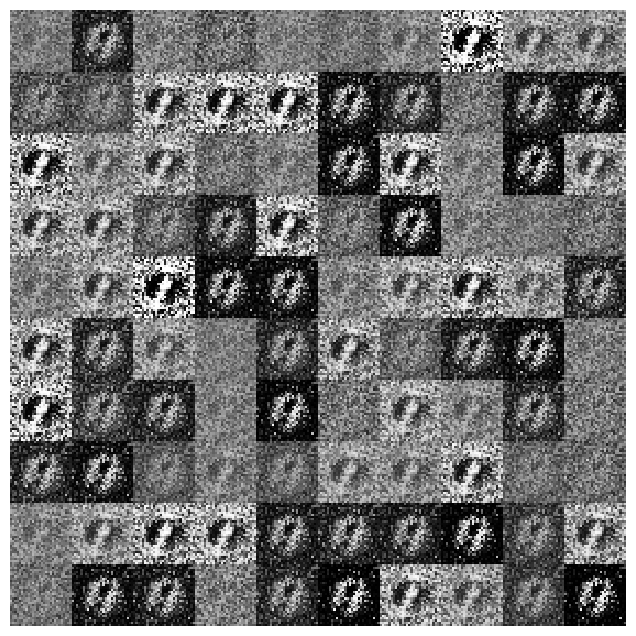

Epoch:   1
D Loss:  0.4991176128387451
G Loss:  1.1596159934997559
Epoch:   2
D Loss:  0.4829399883747101
G Loss:  1.394775152206421


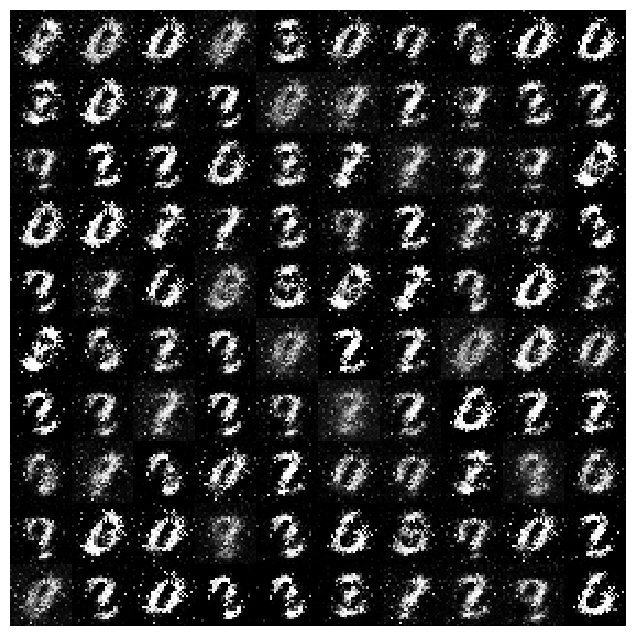

Epoch:   3
D Loss:  0.4962036609649658
G Loss:  1.330749750137329
Epoch:   4
D Loss:  0.5175942182540894
G Loss:  1.9957976341247559


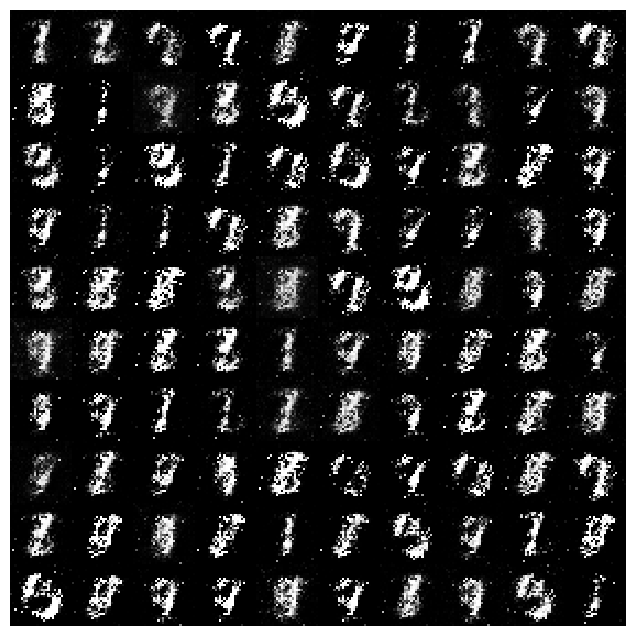

Epoch:   5
D Loss:  0.5161635875701904
G Loss:  1.9628788232803345
Epoch:   6
D Loss:  0.516201913356781
G Loss:  1.0473027229309082


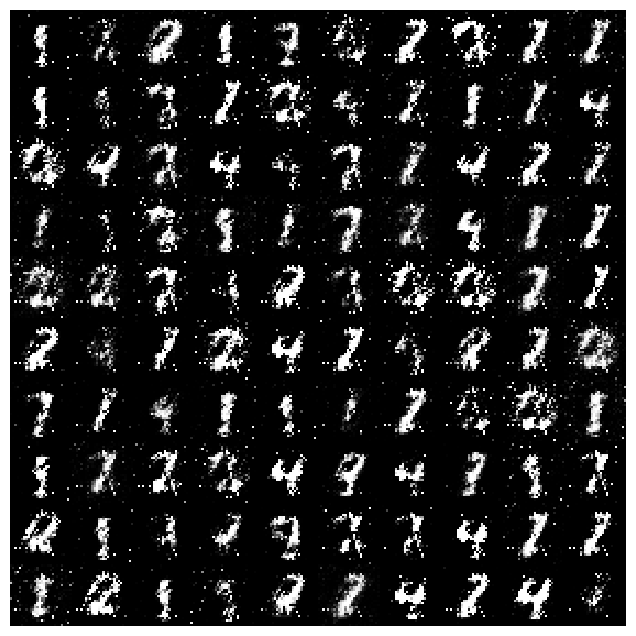

Epoch:   7
D Loss:  0.6442447304725647
G Loss:  2.3737547397613525
Epoch:   8
D Loss:  0.5174028873443604
G Loss:  1.7969001531600952


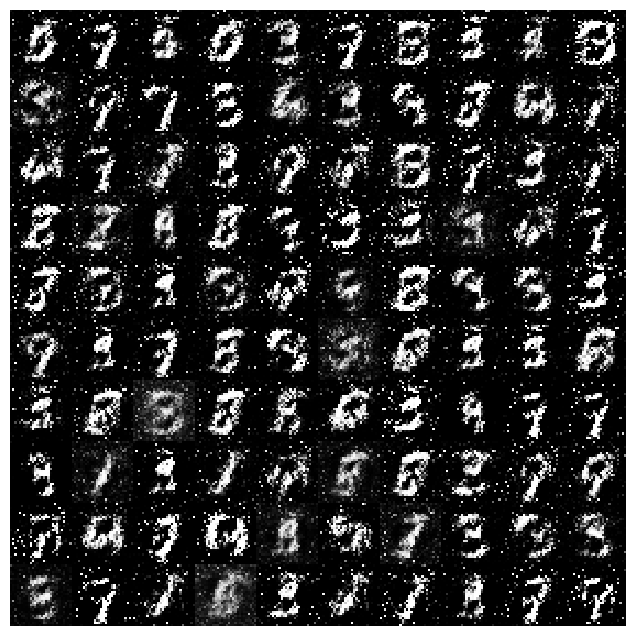

Epoch:   9
D Loss:  0.5383472442626953
G Loss:  0.9505181312561035
Epoch:   10
D Loss:  0.4745815396308899
G Loss:  1.0457345247268677


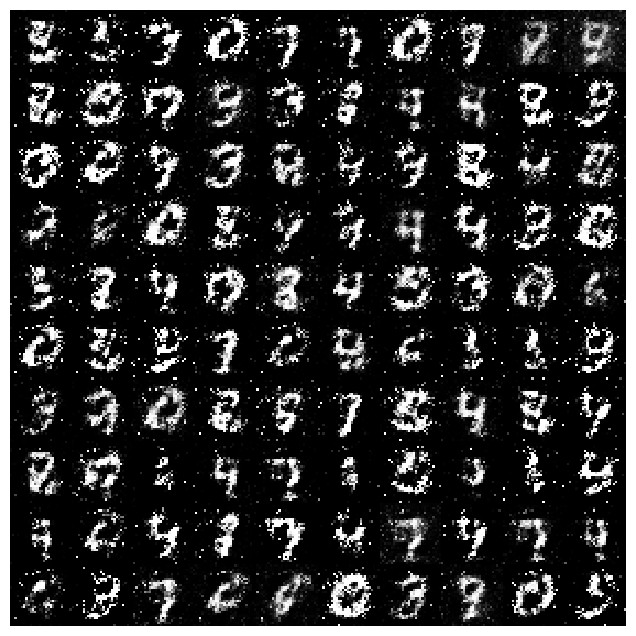

Epoch:   11
D Loss:  0.5695967078208923
G Loss:  1.3152161836624146
Epoch:   12
D Loss:  0.5575109720230103
G Loss:  1.3088538646697998


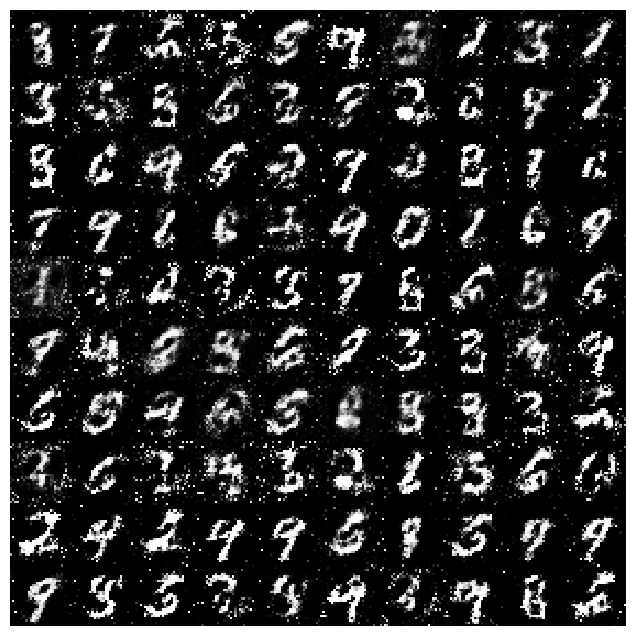

Epoch:   13
D Loss:  0.5672691464424133
G Loss:  1.0460889339447021
Epoch:   14
D Loss:  0.6073839664459229
G Loss:  0.9033252000808716


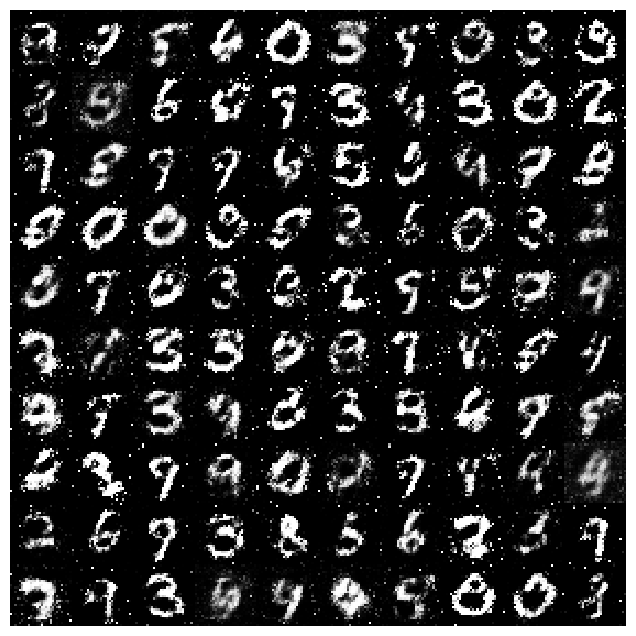

Epoch:   15
D Loss:  0.6232621669769287
G Loss:  0.7203518152236938
Epoch:   16
D Loss:  0.6351783871650696
G Loss:  1.0996185541152954


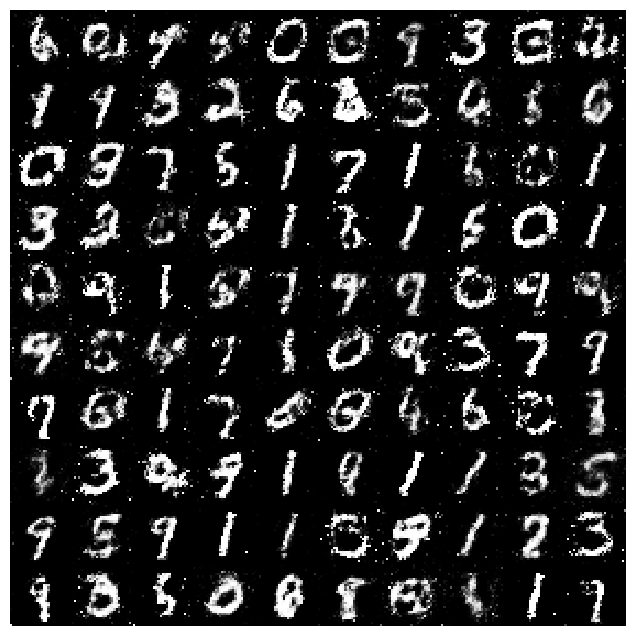

Epoch:   17
D Loss:  0.6340200304985046
G Loss:  1.2334091663360596
Epoch:   18
D Loss:  0.6629400253295898
G Loss:  1.2751169204711914


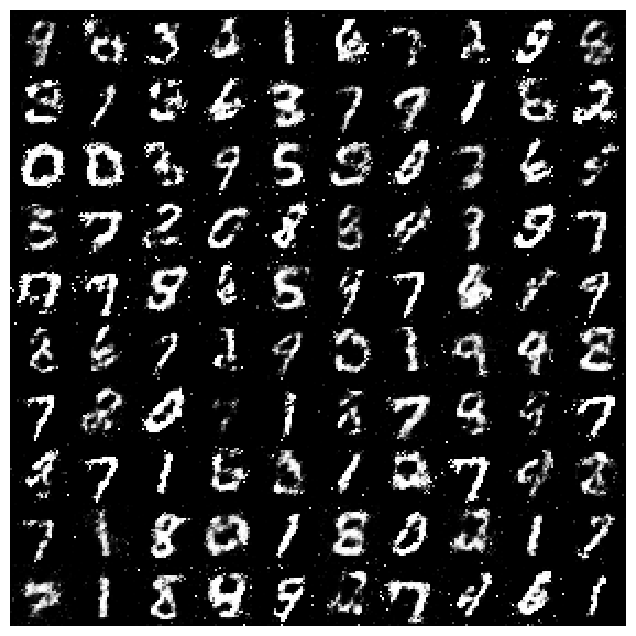

Epoch:   19
D Loss:  0.6165736317634583
G Loss:  0.9759917259216309
Epoch:   20
D Loss:  0.6180049180984497
G Loss:  1.24635910987854


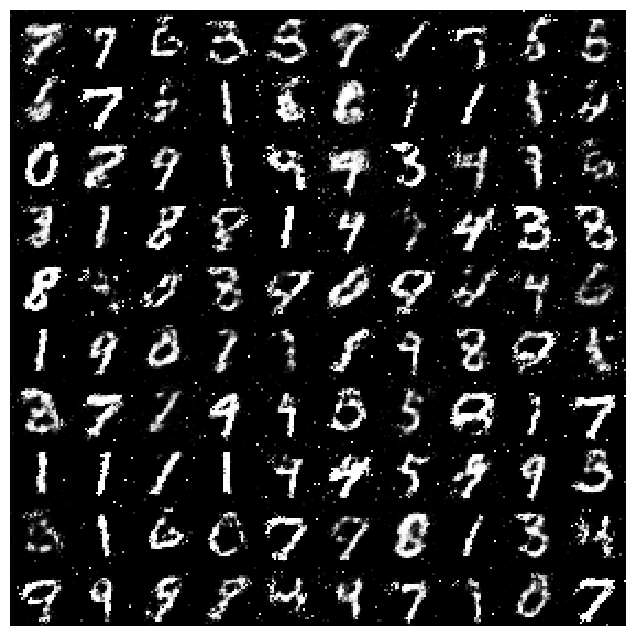

Epoch:   21
D Loss:  0.5943475961685181
G Loss:  0.8190726637840271
Epoch:   22
D Loss:  0.6289751529693604
G Loss:  1.0748825073242188


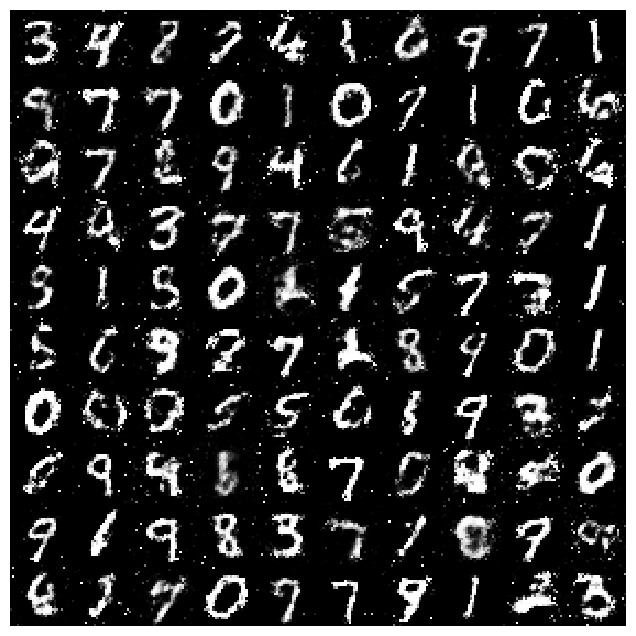

Epoch:   23
D Loss:  0.6221850514411926
G Loss:  0.7987188100814819
Epoch:   24
D Loss:  0.6117699146270752
G Loss:  1.0463677644729614


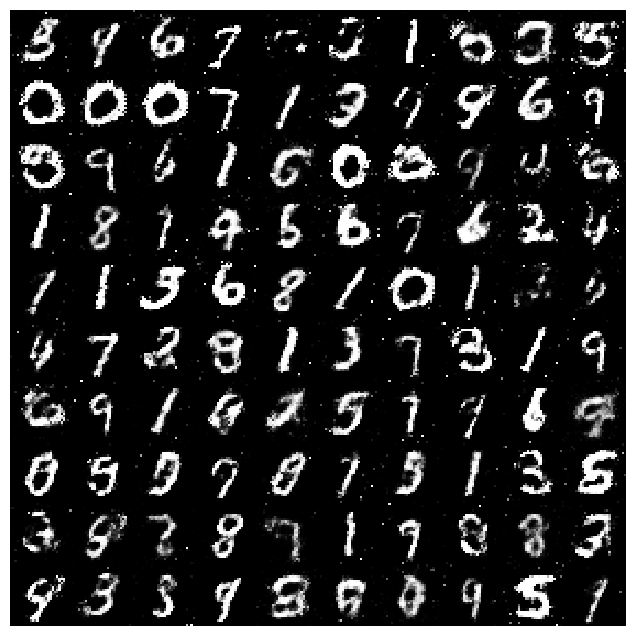

Epoch:   25
D Loss:  0.6530326008796692
G Loss:  0.567254900932312
Epoch:   26
D Loss:  0.6104196310043335
G Loss:  0.6446825265884399


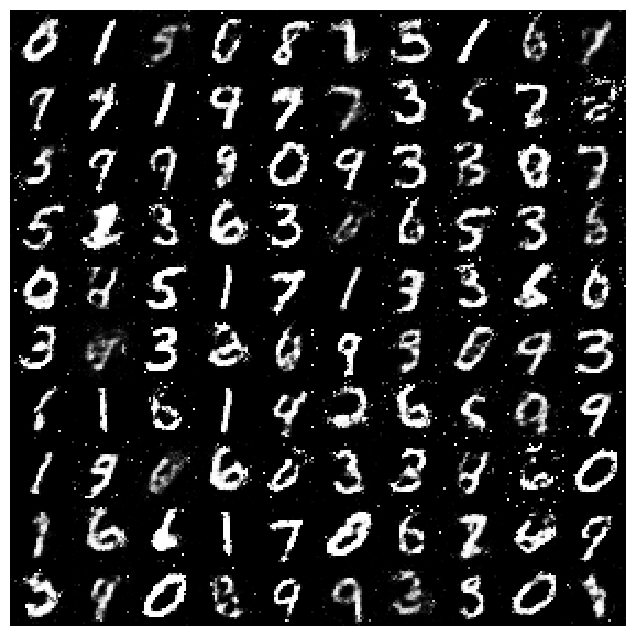

Epoch:   27
D Loss:  0.6154311299324036
G Loss:  0.9084506034851074
Epoch:   28
D Loss:  0.6291030645370483
G Loss:  0.9218235611915588


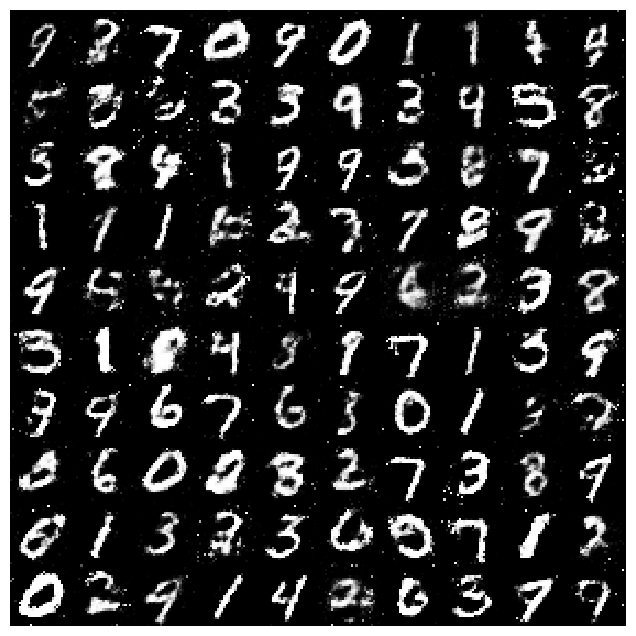

Epoch:   29
D Loss:  0.6081846356391907
G Loss:  1.0277440547943115
Epoch:   30
D Loss:  0.6284467577934265
G Loss:  0.9146093726158142


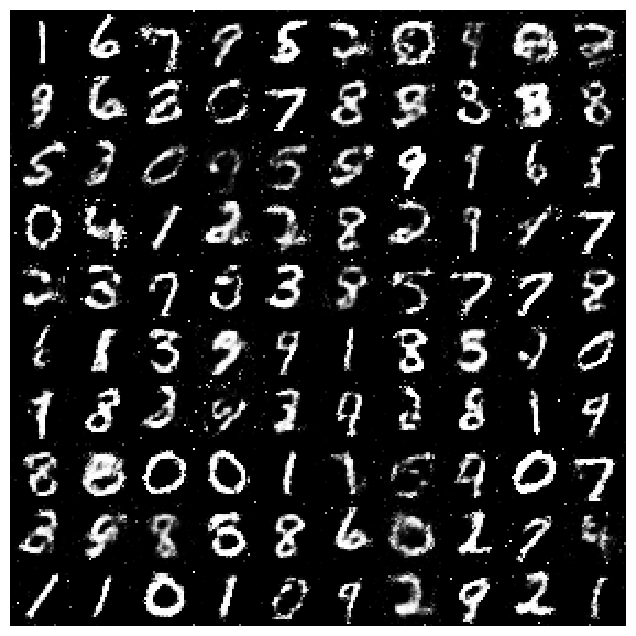

Epoch:   31
D Loss:  0.6140981912612915
G Loss:  0.7552733421325684
Epoch:   32
D Loss:  0.6184223890304565
G Loss:  0.6925385594367981


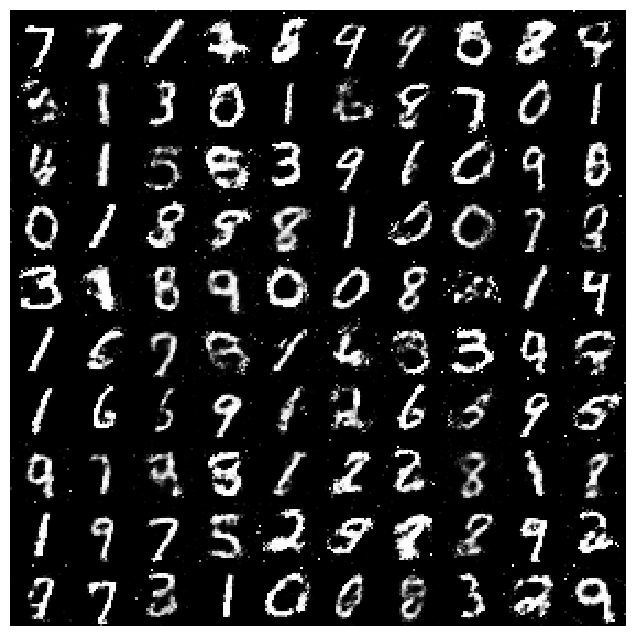

Epoch:   33
D Loss:  0.6411420106887817
G Loss:  1.2914280891418457
Epoch:   34
D Loss:  0.626625657081604
G Loss:  0.8714032769203186


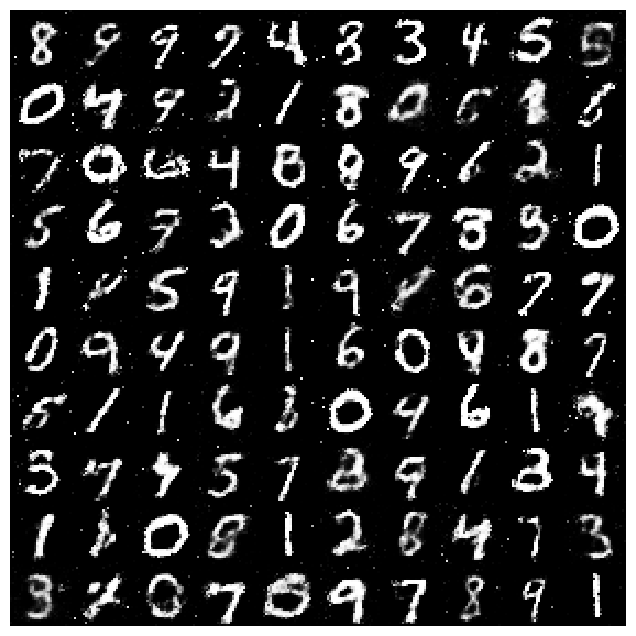

Epoch:   35
D Loss:  0.6152513027191162
G Loss:  0.9396045804023743
Epoch:   36
D Loss:  0.6031366586685181
G Loss:  0.954715371131897


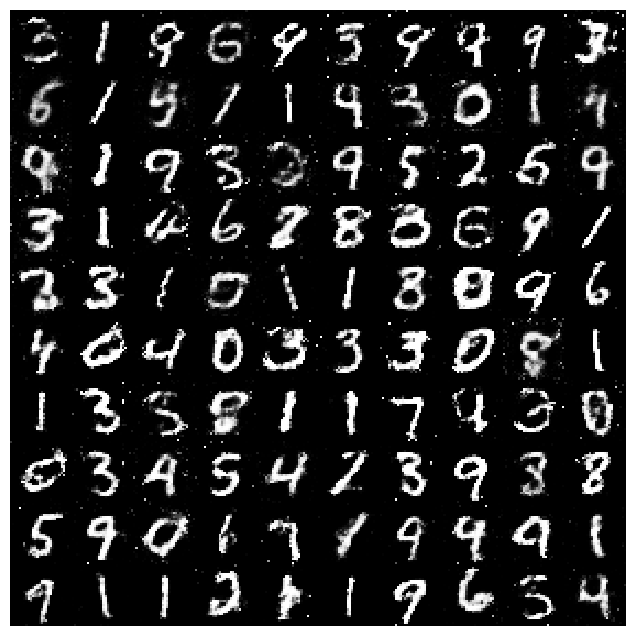

Epoch:   37
D Loss:  0.6027346849441528
G Loss:  1.0272424221038818
Epoch:   38
D Loss:  0.6007330417633057
G Loss:  0.8990594148635864


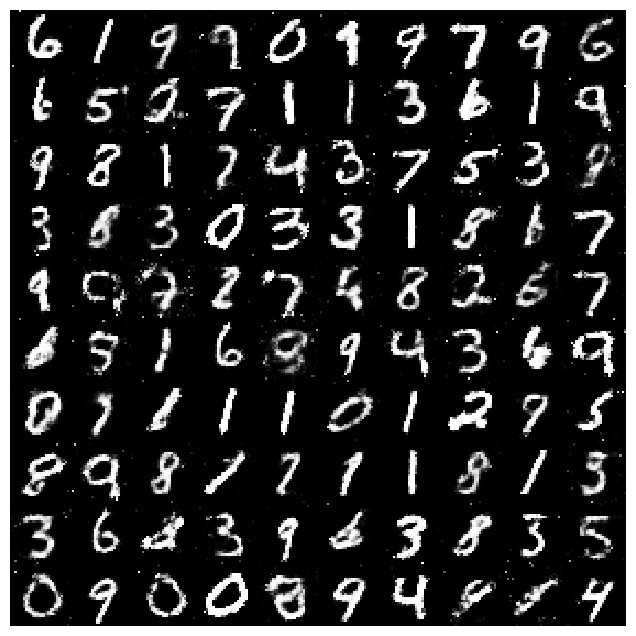

Epoch:   39
D Loss:  0.608051061630249
G Loss:  0.876927375793457
Epoch:   40
D Loss:  0.6071301698684692
G Loss:  0.9957923293113708


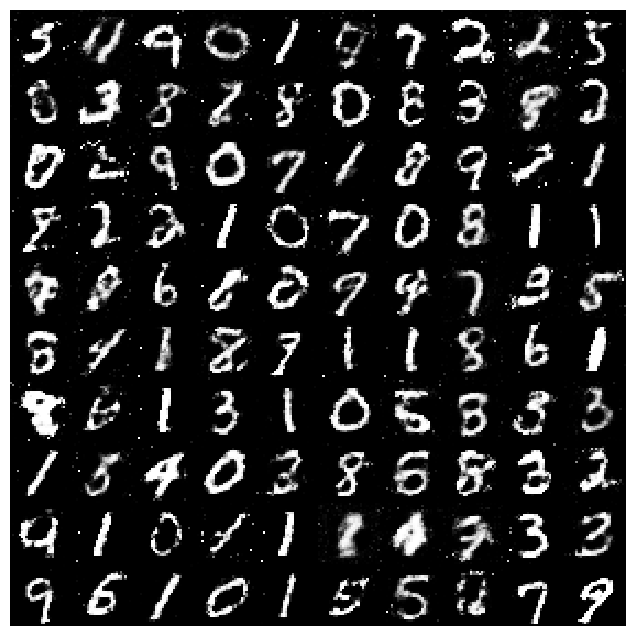

Epoch:   41
D Loss:  0.6340069770812988
G Loss:  0.9974262714385986
Epoch:   42
D Loss:  0.6146045327186584
G Loss:  0.6904557943344116


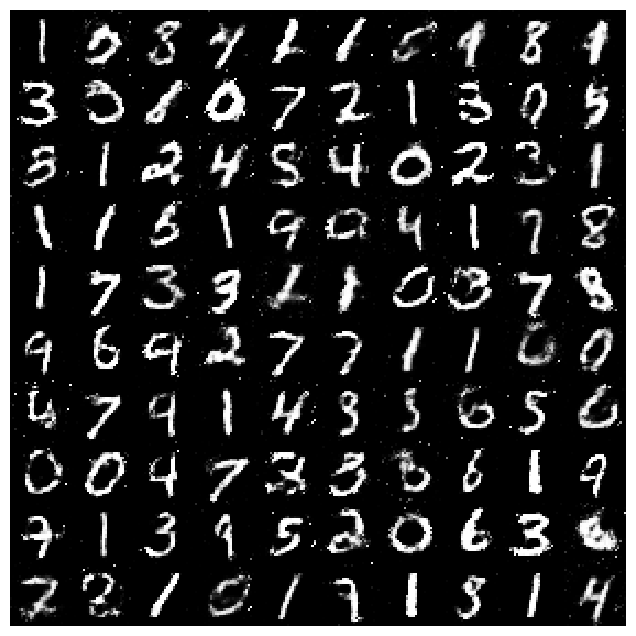

Epoch:   43
D Loss:  0.5759706497192383
G Loss:  0.8883675932884216
Epoch:   44
D Loss:  0.6311708688735962
G Loss:  0.8660571575164795


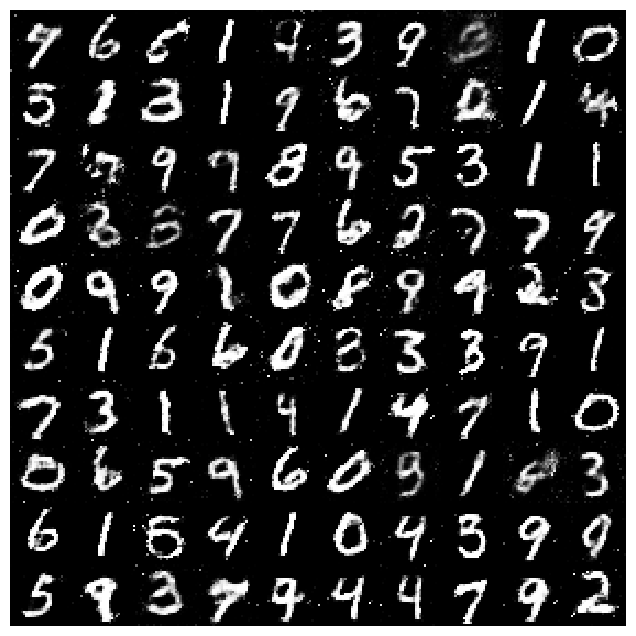

Epoch:   45
D Loss:  0.582633376121521
G Loss:  1.0764212608337402
Epoch:   46
D Loss:  0.6457390785217285
G Loss:  0.8188685774803162


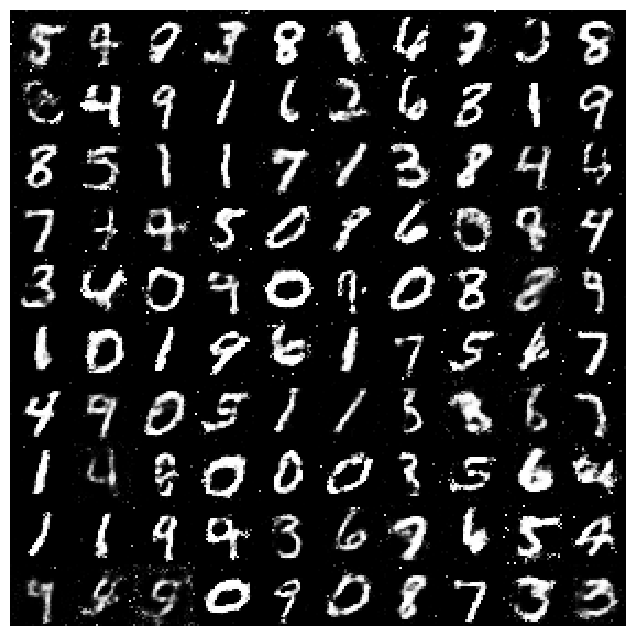

Epoch:   47
D Loss:  0.6782387495040894
G Loss:  1.3429579734802246
Epoch:   48
D Loss:  0.6245945692062378
G Loss:  1.1559343338012695


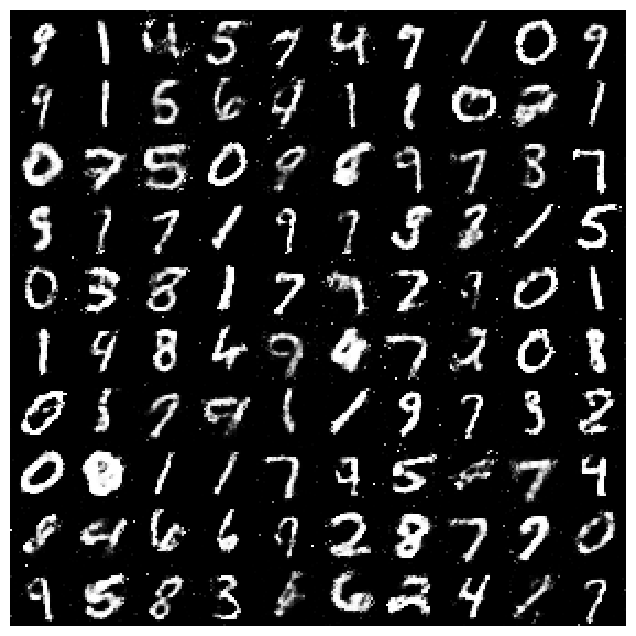

Epoch:   49
D Loss:  0.6938689947128296
G Loss:  0.5251606106758118
Epoch:   50
D Loss:  0.6144253015518188
G Loss:  0.751089334487915


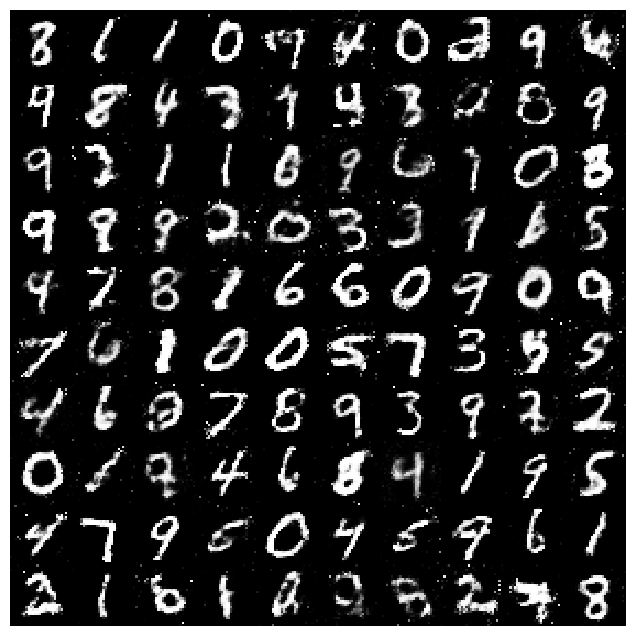

Epoch:   51
D Loss:  0.6417394876480103
G Loss:  1.1210639476776123
Epoch:   52
D Loss:  0.614885687828064
G Loss:  1.2723679542541504


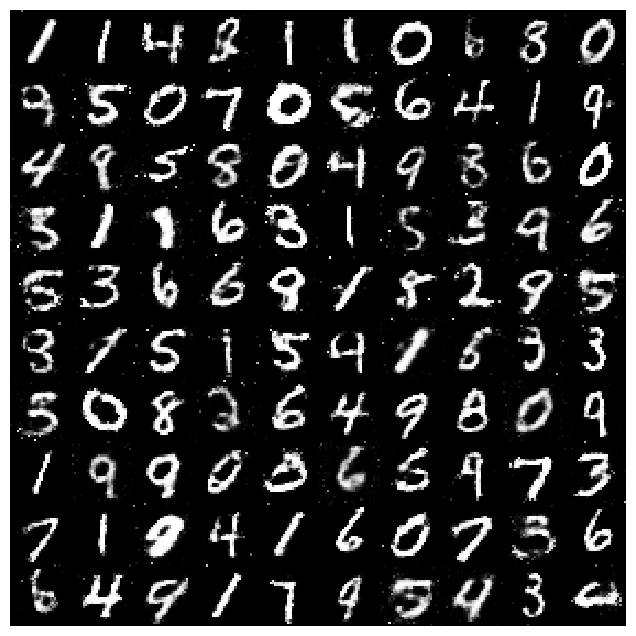

Epoch:   53
D Loss:  0.5980855822563171
G Loss:  0.9783279299736023
Epoch:   54
D Loss:  0.5697199702262878
G Loss:  0.9539494514465332


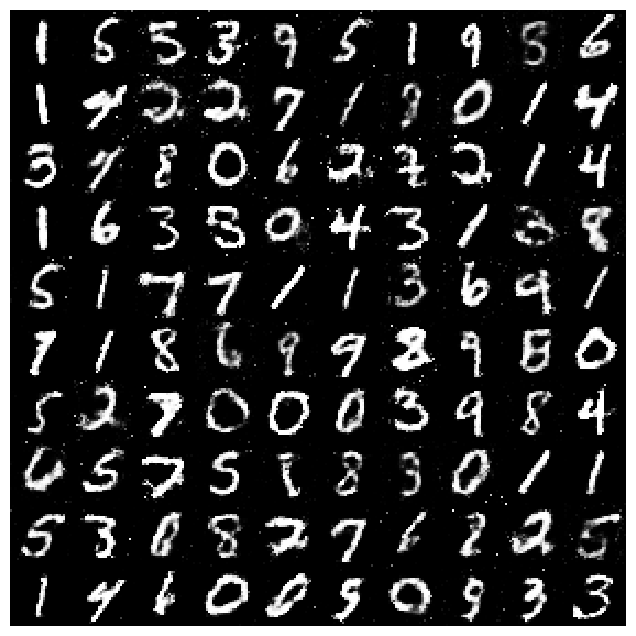

Epoch:   55
D Loss:  0.6021836400032043
G Loss:  1.1995899677276611
Epoch:   56
D Loss:  0.5856753587722778
G Loss:  0.9879145622253418


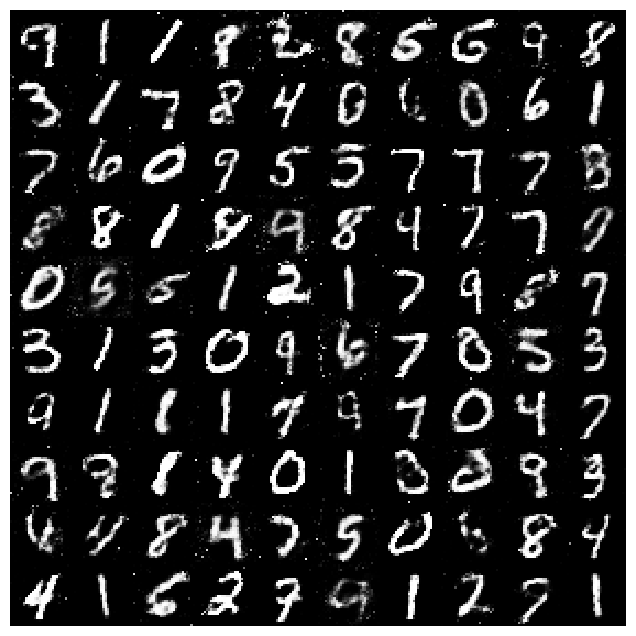

Epoch:   57
D Loss:  0.6392030715942383
G Loss:  0.7281237840652466
Epoch:   58
D Loss:  0.605940580368042
G Loss:  0.8816323280334473


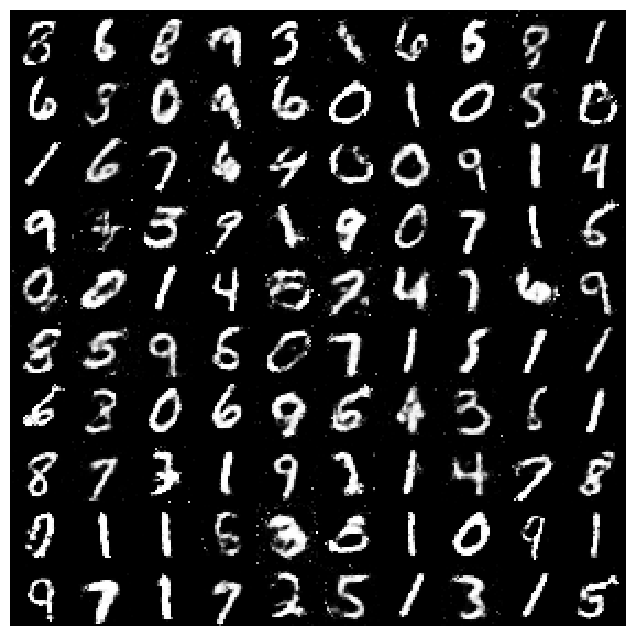

Epoch:   59
D Loss:  0.6074924468994141
G Loss:  0.9722625017166138
Epoch:   60
D Loss:  0.6213852167129517
G Loss:  1.0920007228851318


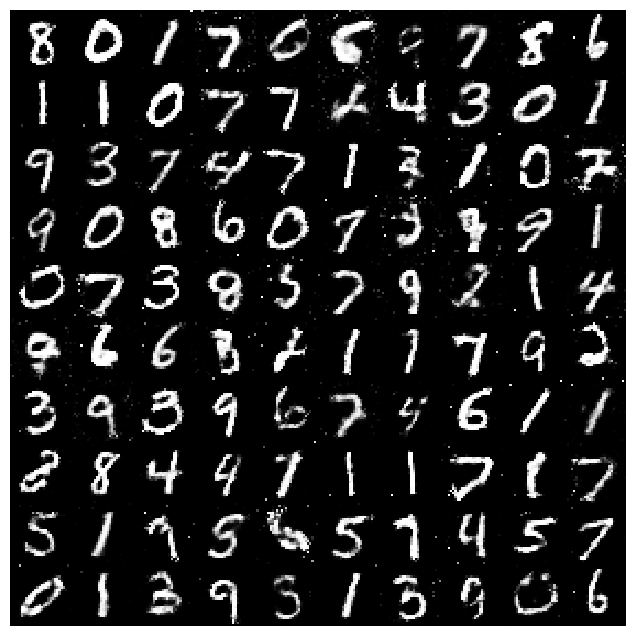

Epoch:   61
D Loss:  0.5744091272354126
G Loss:  0.9187591075897217
Epoch:   62
D Loss:  0.5807338953018188
G Loss:  1.110929250717163


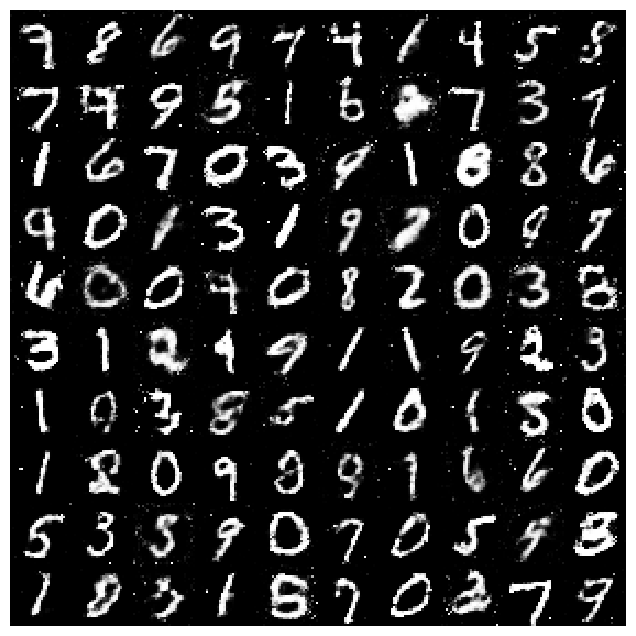

Epoch:   63
D Loss:  0.5843768119812012
G Loss:  0.8254848718643188
Epoch:   64
D Loss:  0.5871018171310425
G Loss:  0.8476772308349609


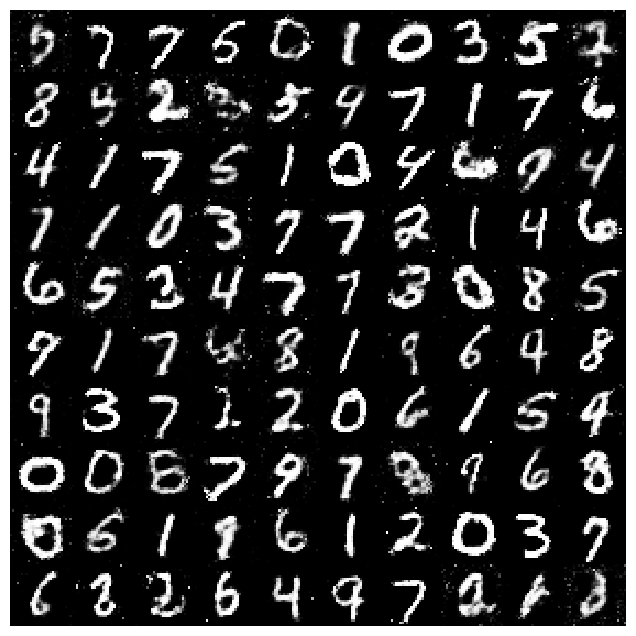

Epoch:   65
D Loss:  0.6067383289337158
G Loss:  1.0956591367721558
Epoch:   66
D Loss:  0.6447936296463013
G Loss:  0.8411026000976562


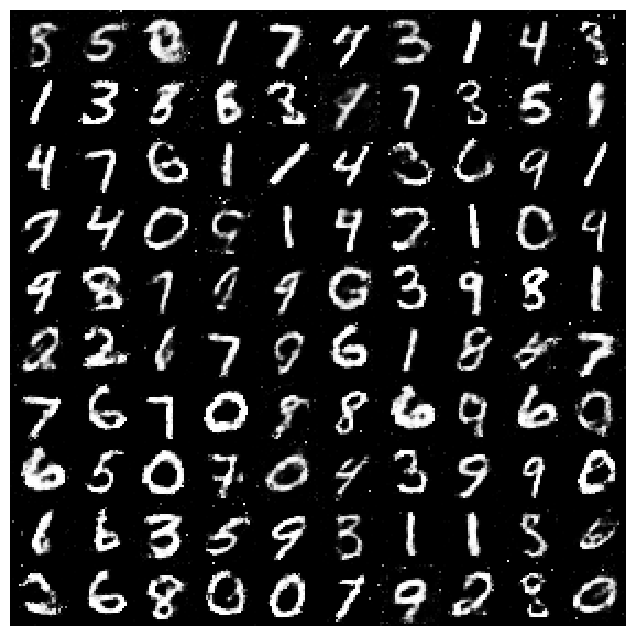

Epoch:   67
D Loss:  0.5737944841384888
G Loss:  1.0744904279708862
Epoch:   68
D Loss:  0.6112284660339355
G Loss:  0.7556623220443726


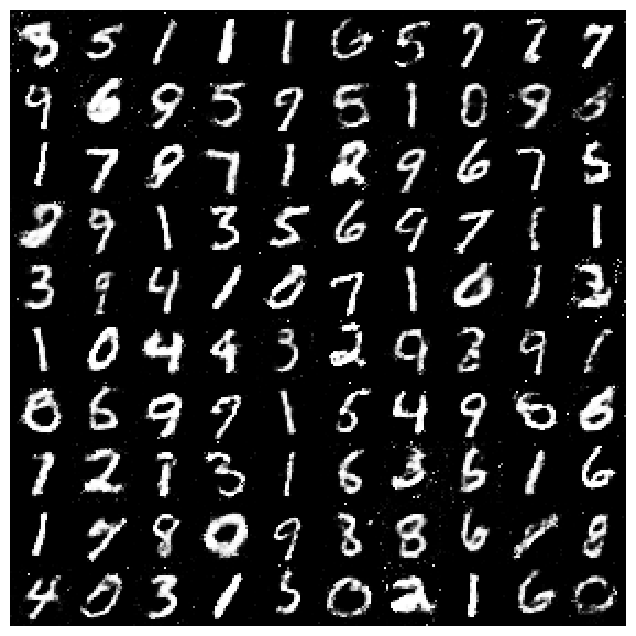

Epoch:   69
D Loss:  0.5868288278579712
G Loss:  1.0021235942840576
Epoch:   70
D Loss:  0.6019617319107056
G Loss:  1.249382734298706


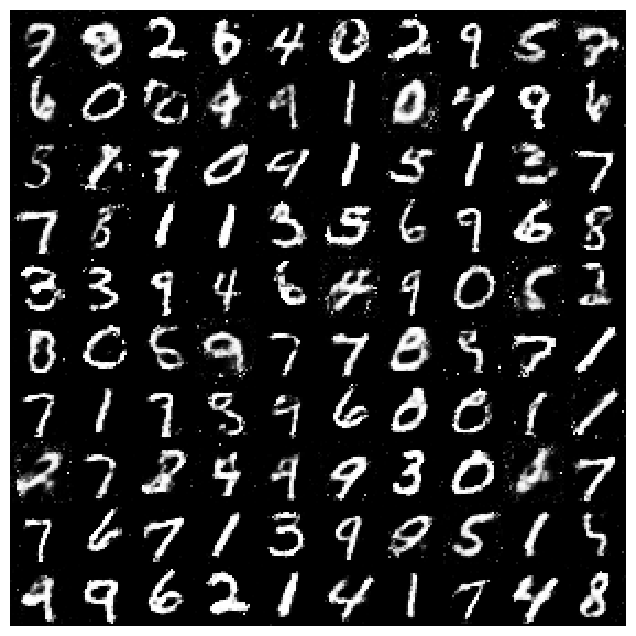

Epoch:   71
D Loss:  0.5906274318695068
G Loss:  1.1636097431182861
Epoch:   72
D Loss:  0.5904866456985474
G Loss:  0.9538259506225586


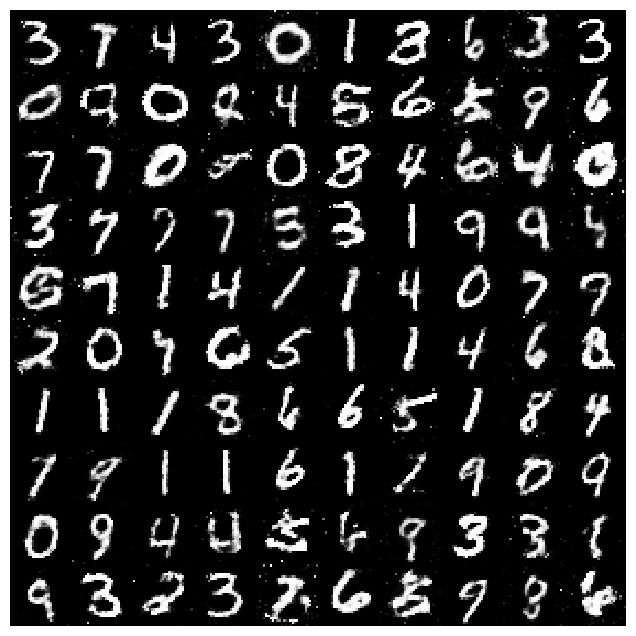

Epoch:   73
D Loss:  0.5938295125961304
G Loss:  1.10715913772583
Epoch:   74
D Loss:  0.6224943399429321
G Loss:  0.8509663343429565


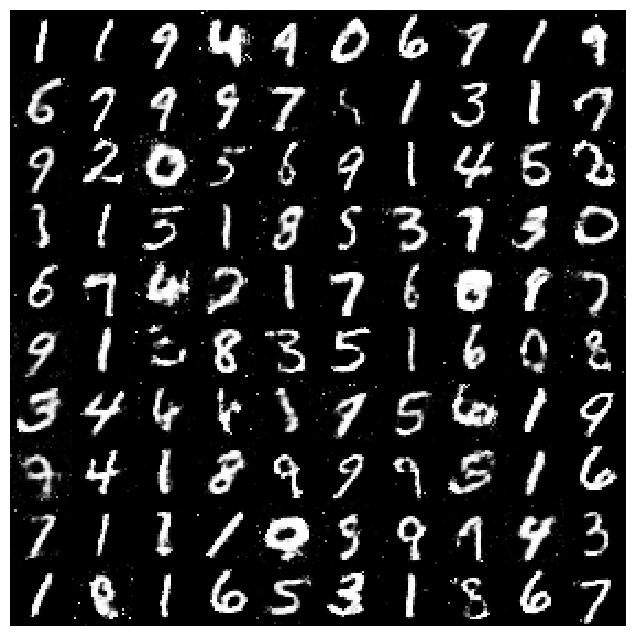

Epoch:   75
D Loss:  0.5822176933288574
G Loss:  1.126692771911621
Epoch:   76
D Loss:  0.5977351069450378
G Loss:  1.1416714191436768


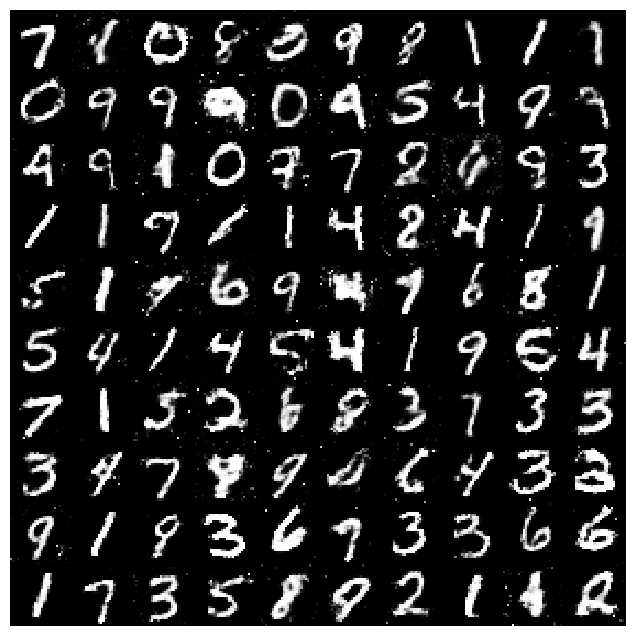

Epoch:   77
D Loss:  0.5768259763717651
G Loss:  0.9902039170265198
Epoch:   78
D Loss:  0.595238447189331
G Loss:  0.9655036926269531


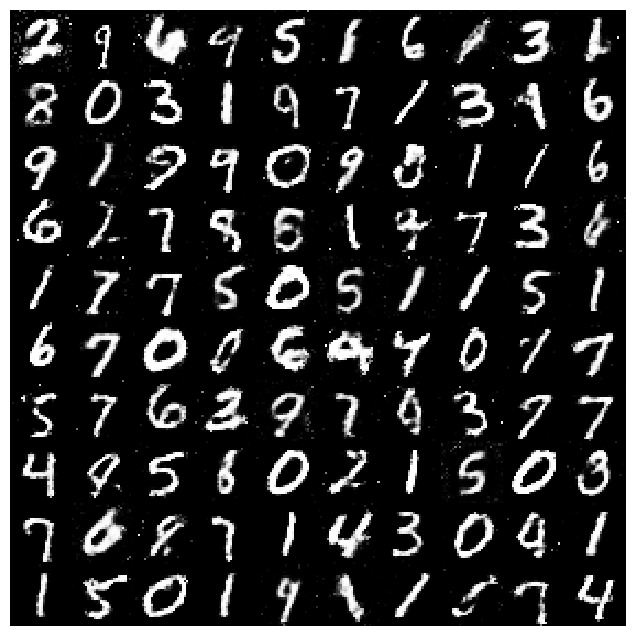

Epoch:   79
D Loss:  0.5859280824661255
G Loss:  0.8782922625541687
Epoch:   80
D Loss:  0.6018072366714478
G Loss:  1.0590720176696777


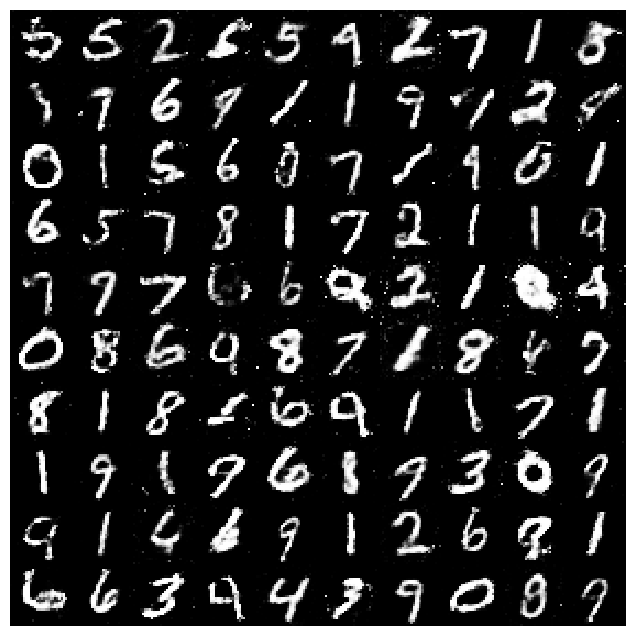

Epoch:   81
D Loss:  0.6176762580871582
G Loss:  0.7008153200149536
Epoch:   82
D Loss:  0.6002057194709778
G Loss:  0.9762135744094849


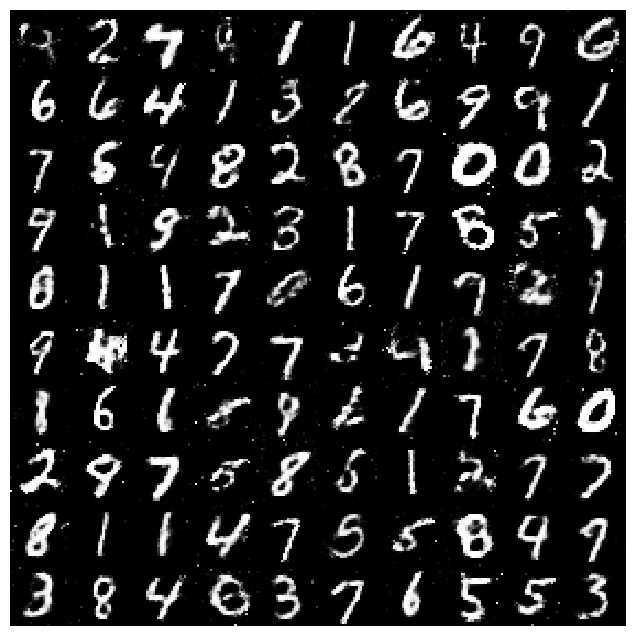

Epoch:   83
D Loss:  0.6051489114761353
G Loss:  0.7395541667938232
Epoch:   84
D Loss:  0.6024441123008728
G Loss:  1.0794081687927246


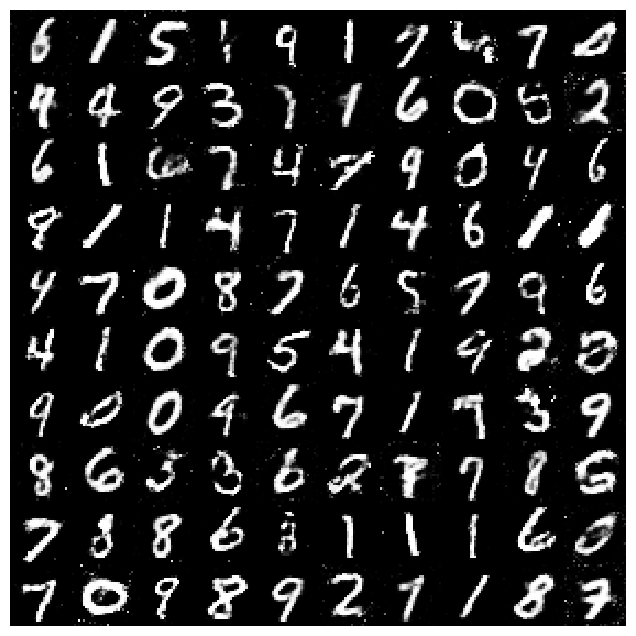

Epoch:   85
D Loss:  0.5675580501556396
G Loss:  1.1552789211273193
Epoch:   86
D Loss:  0.5867272615432739
G Loss:  0.7223423719406128


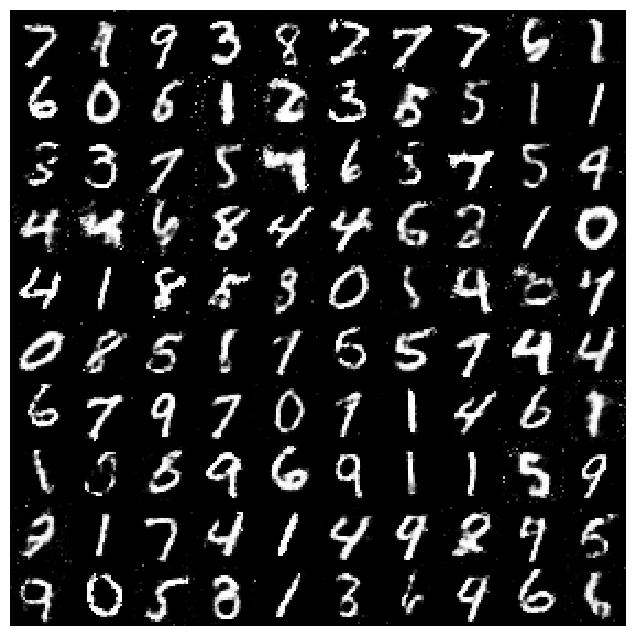

Epoch:   87
D Loss:  0.5983002185821533
G Loss:  0.9541598558425903
Epoch:   88
D Loss:  0.6117680072784424
G Loss:  0.9087705612182617


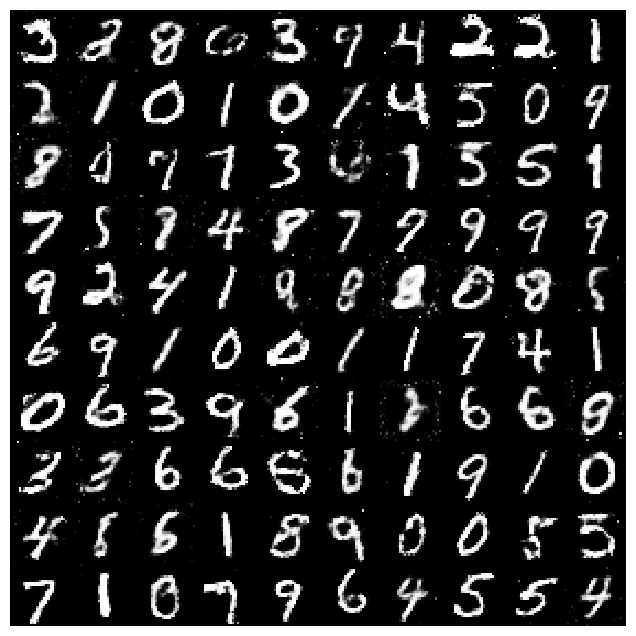

Epoch:   89
D Loss:  0.5938628911972046
G Loss:  0.7553164958953857
Epoch:   90
D Loss:  0.5791009664535522
G Loss:  1.2309074401855469


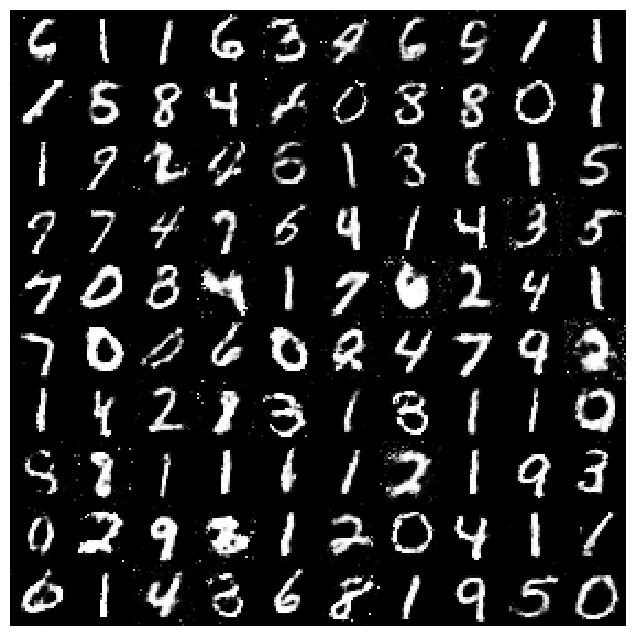

Epoch:   91
D Loss:  0.5906417369842529
G Loss:  0.7835135459899902
Epoch:   92
D Loss:  0.5950074195861816
G Loss:  1.1887760162353516


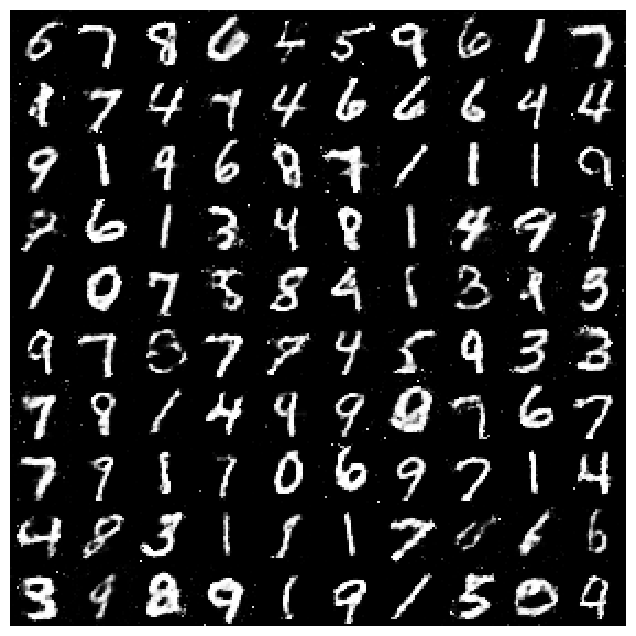

Epoch:   93
D Loss:  0.5782091617584229
G Loss:  0.9748548269271851
Epoch:   94
D Loss:  0.5869917869567871
G Loss:  1.257700800895691


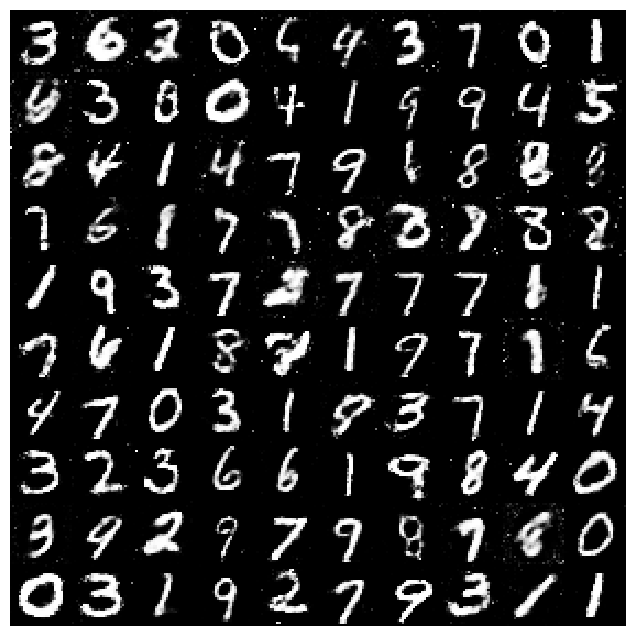

Epoch:   95
D Loss:  0.6234874725341797
G Loss:  0.8286662697792053
Epoch:   96
D Loss:  0.5606788396835327
G Loss:  1.0786221027374268


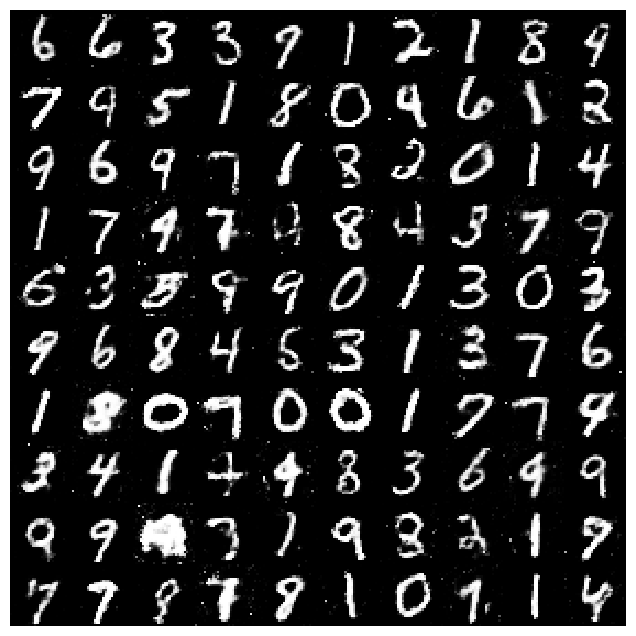

Epoch:   97
D Loss:  0.6038427352905273
G Loss:  0.8316442966461182
Epoch:   98
D Loss:  0.5916587710380554
G Loss:  1.251631259918213


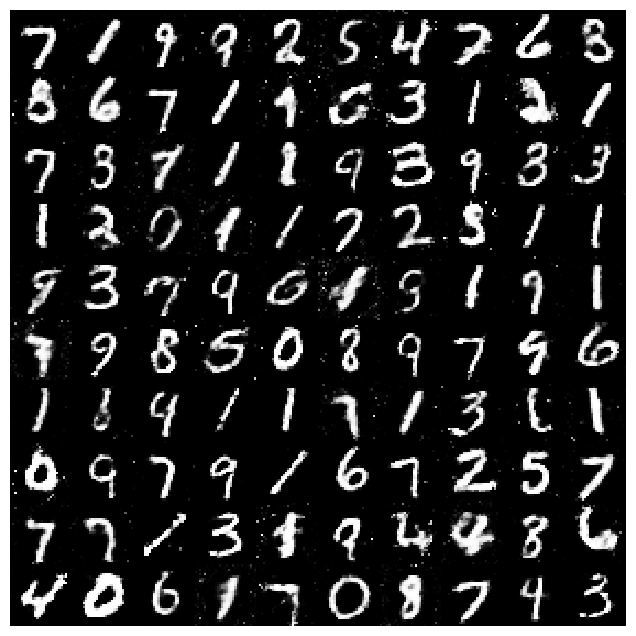

Epoch:   99
D Loss:  0.6284568309783936
G Loss:  0.8294868469238281
Epoch:   100
D Loss:  0.594878613948822
G Loss:  0.9335635900497437


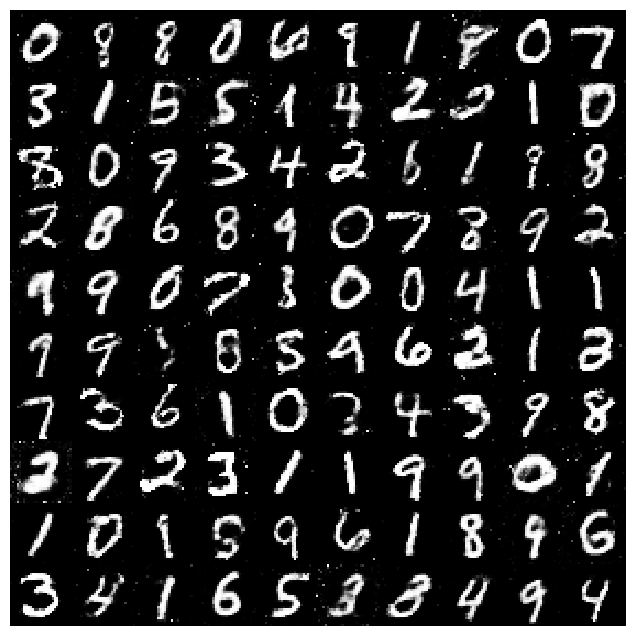

Epoch:   101
D Loss:  0.5804480314254761
G Loss:  1.299416184425354
Epoch:   102
D Loss:  0.5708253383636475
G Loss:  0.9337644577026367


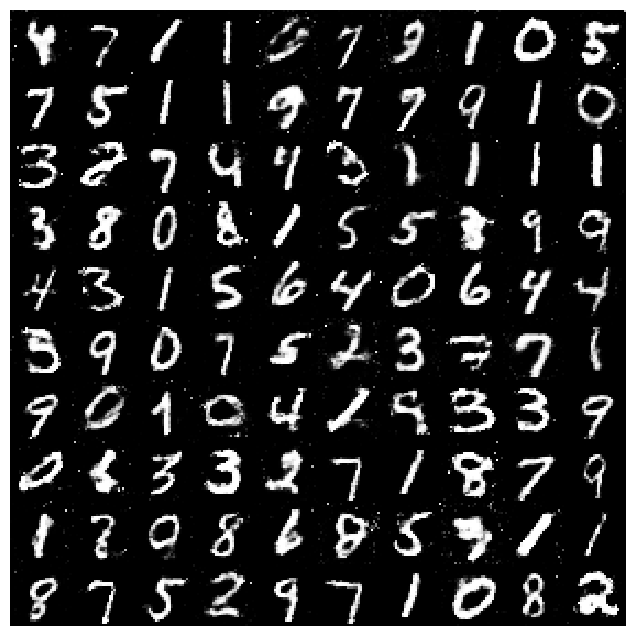

Epoch:   103
D Loss:  0.5987132787704468
G Loss:  1.1134172677993774
Epoch:   104
D Loss:  0.6072139739990234
G Loss:  0.8489513397216797


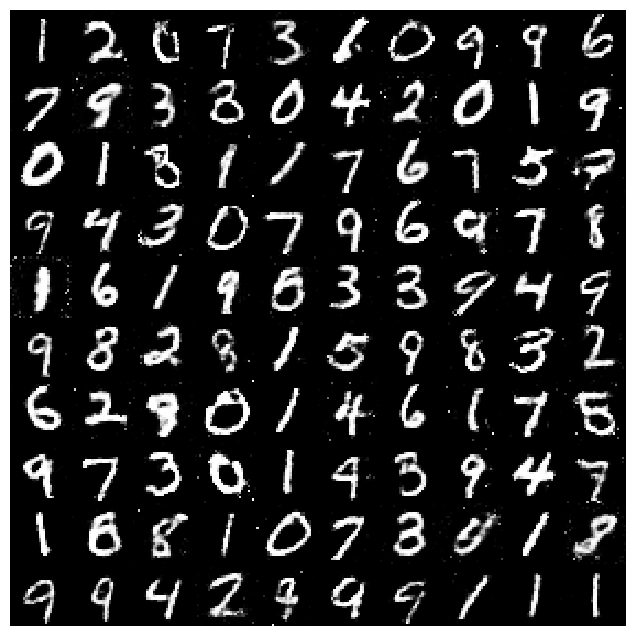

Epoch:   105
D Loss:  0.5672280788421631
G Loss:  0.84056556224823
Epoch:   106
D Loss:  0.5743430852890015
G Loss:  1.053023338317871


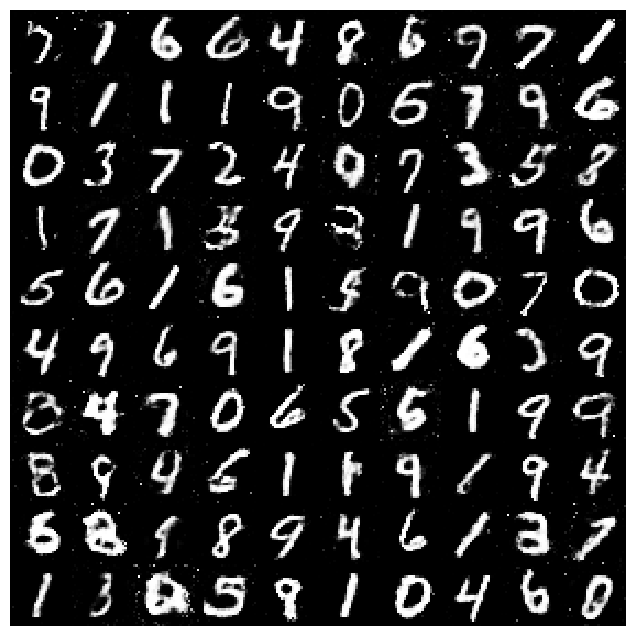

Epoch:   107
D Loss:  0.6264983415603638
G Loss:  1.1803799867630005
Epoch:   108
D Loss:  0.5956994295120239
G Loss:  0.8994053602218628


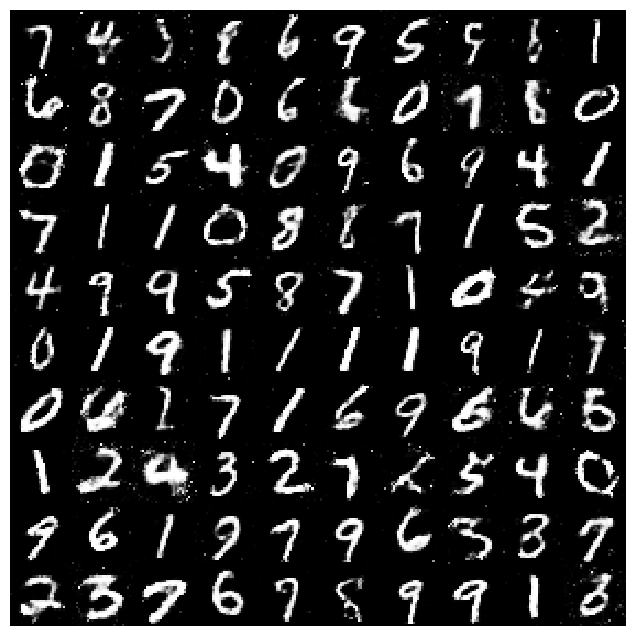

Epoch:   109
D Loss:  0.5987534523010254
G Loss:  1.2141780853271484
Epoch:   110
D Loss:  0.6047849655151367
G Loss:  0.8721872568130493


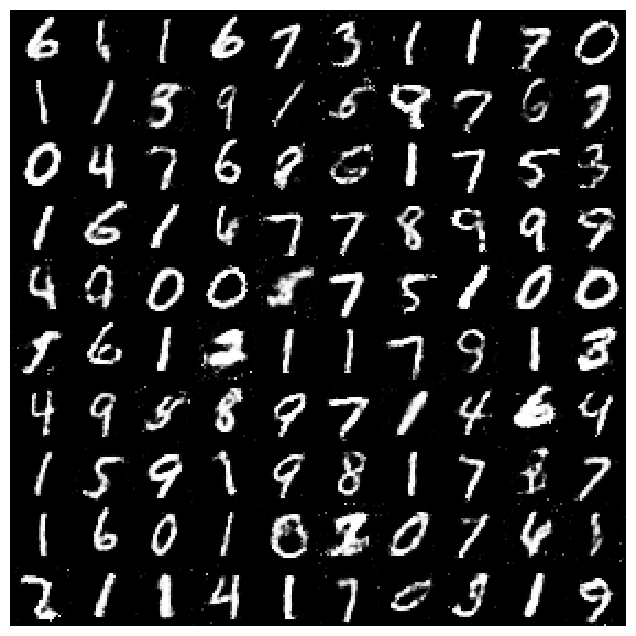

Epoch:   111
D Loss:  0.5696149468421936
G Loss:  1.0536811351776123
Epoch:   112
D Loss:  0.5770605802536011
G Loss:  1.21564781665802


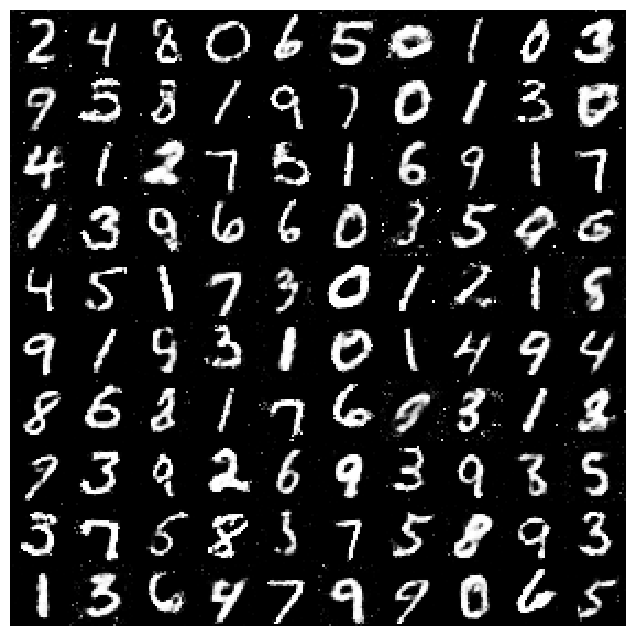

Epoch:   113
D Loss:  0.5851787328720093
G Loss:  0.7717751860618591
Epoch:   114
D Loss:  0.6042690873146057
G Loss:  1.1306812763214111


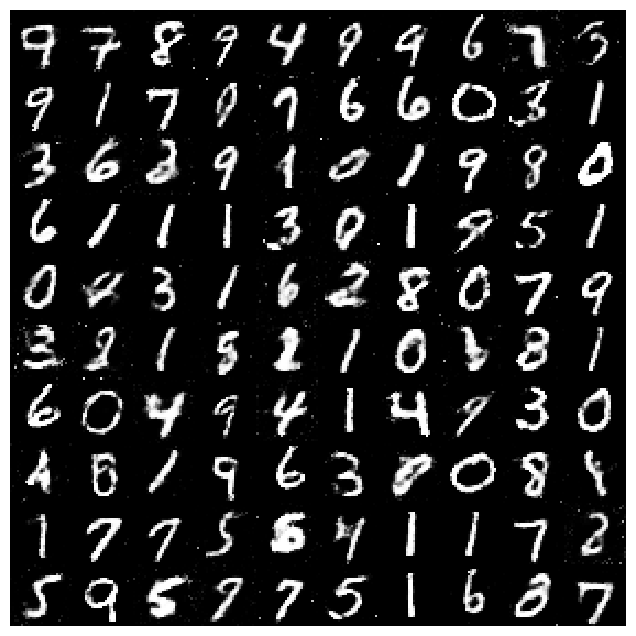

Epoch:   115
D Loss:  0.5977867245674133
G Loss:  0.9596832990646362
Epoch:   116
D Loss:  0.6178040504455566
G Loss:  0.9581342935562134


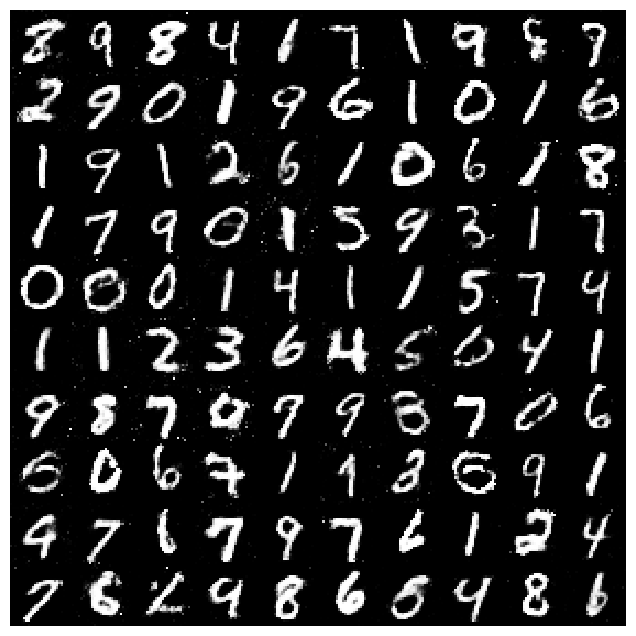

Epoch:   117
D Loss:  0.6257351040840149
G Loss:  0.9296367168426514
Epoch:   118
D Loss:  0.5876933336257935
G Loss:  1.0121572017669678


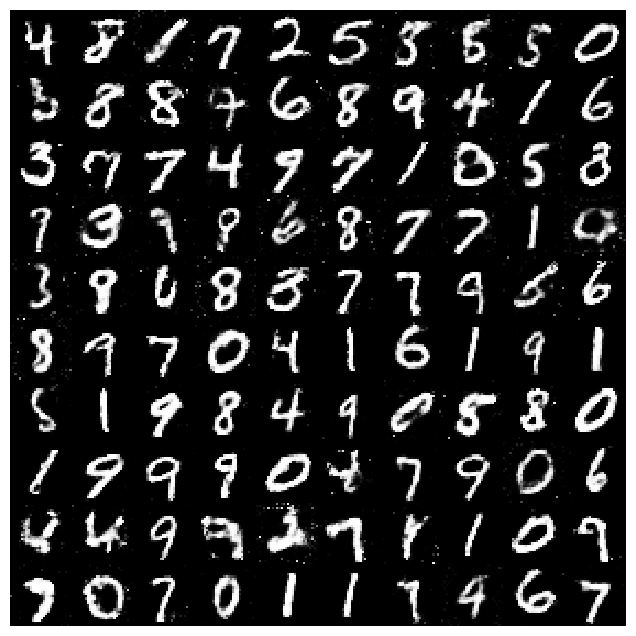

Epoch:   119
D Loss:  0.667960524559021
G Loss:  1.4528405666351318
Epoch:   120
D Loss:  0.6038904190063477
G Loss:  1.1689918041229248


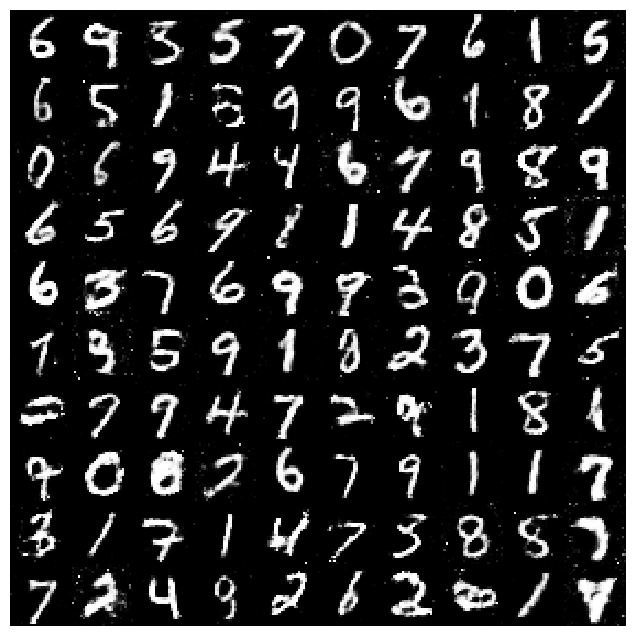

Epoch:   121
D Loss:  0.5827634334564209
G Loss:  0.9188063144683838
Epoch:   122
D Loss:  0.597508430480957
G Loss:  1.0422382354736328


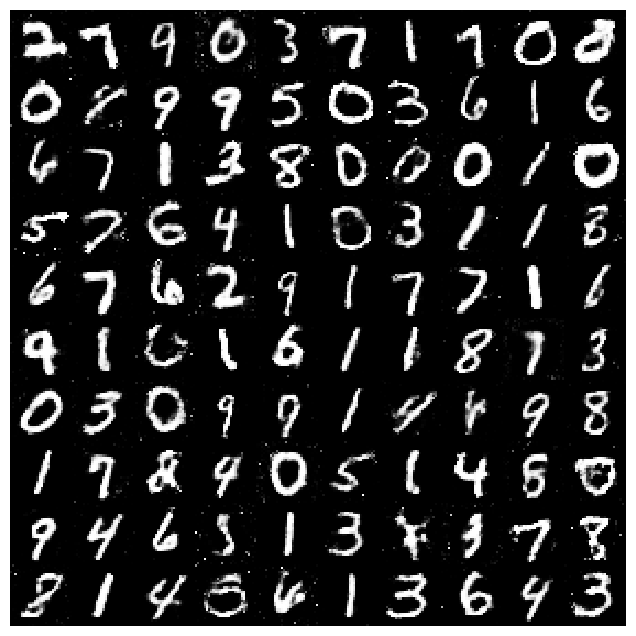

Epoch:   123
D Loss:  0.5533064007759094
G Loss:  1.0315990447998047
Epoch:   124
D Loss:  0.620938777923584
G Loss:  1.1939356327056885


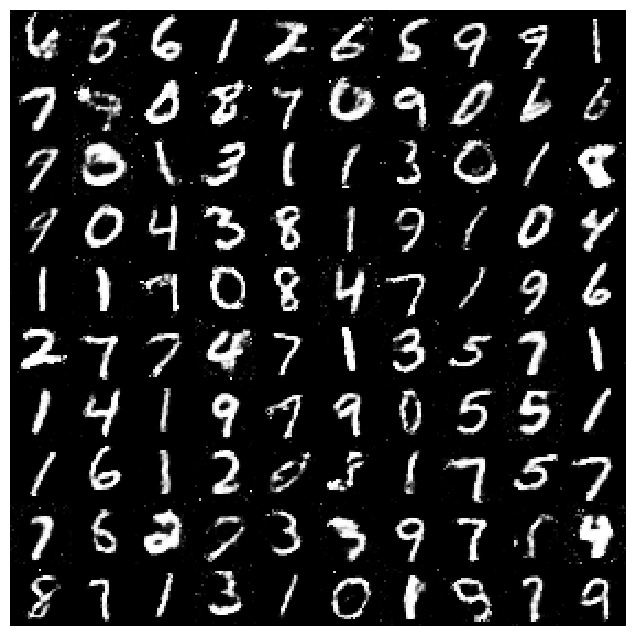

Epoch:   125
D Loss:  0.5879721641540527
G Loss:  0.8576456308364868
Epoch:   126
D Loss:  0.5886330008506775
G Loss:  0.8480298519134521


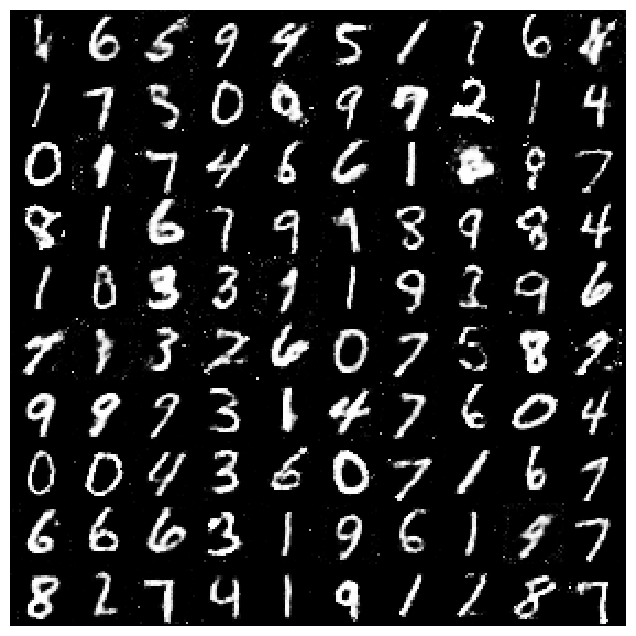

Epoch:   127
D Loss:  0.5977710485458374
G Loss:  1.503859281539917
Epoch:   128
D Loss:  0.5934937596321106
G Loss:  0.9466668367385864


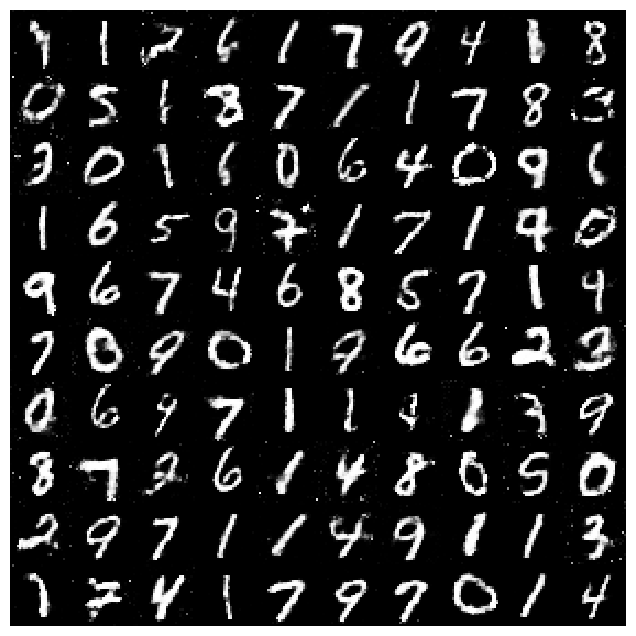

Epoch:   129
D Loss:  0.5571715831756592
G Loss:  0.9736376404762268
Epoch:   130
D Loss:  0.6073535680770874
G Loss:  1.1723294258117676


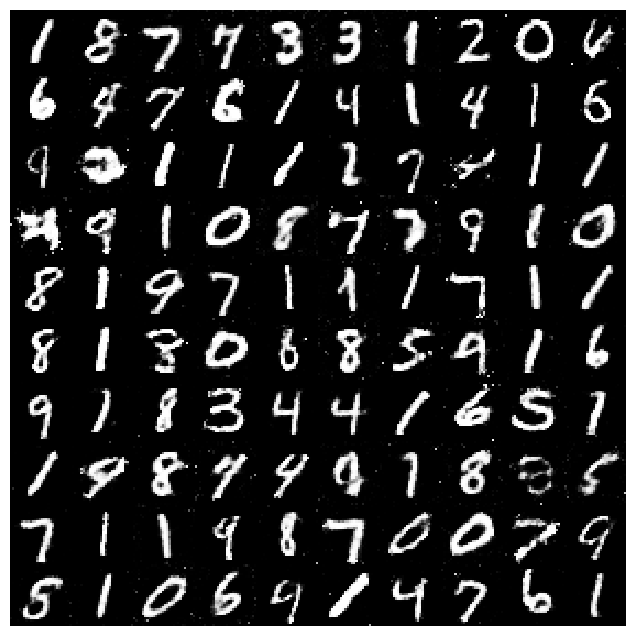

Epoch:   131
D Loss:  0.6308527588844299
G Loss:  0.7813717126846313
Epoch:   132
D Loss:  0.5932928323745728
G Loss:  1.077584981918335


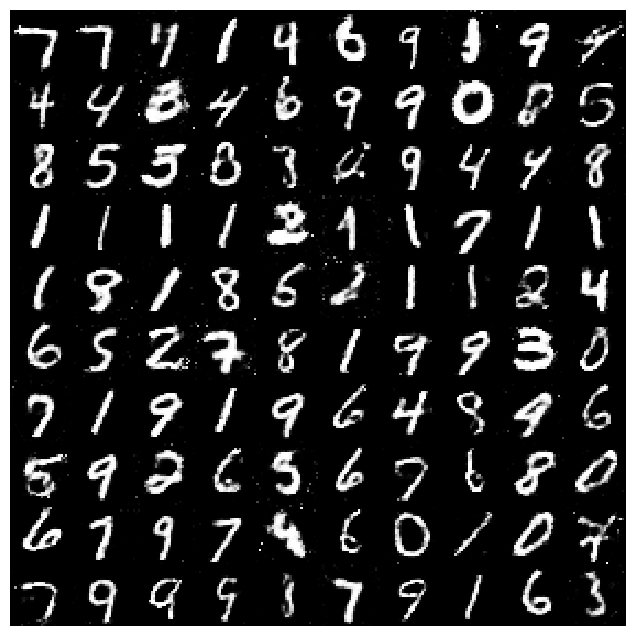

Epoch:   133
D Loss:  0.6273087859153748
G Loss:  1.1299498081207275
Epoch:   134
D Loss:  0.5648207664489746
G Loss:  1.126798391342163


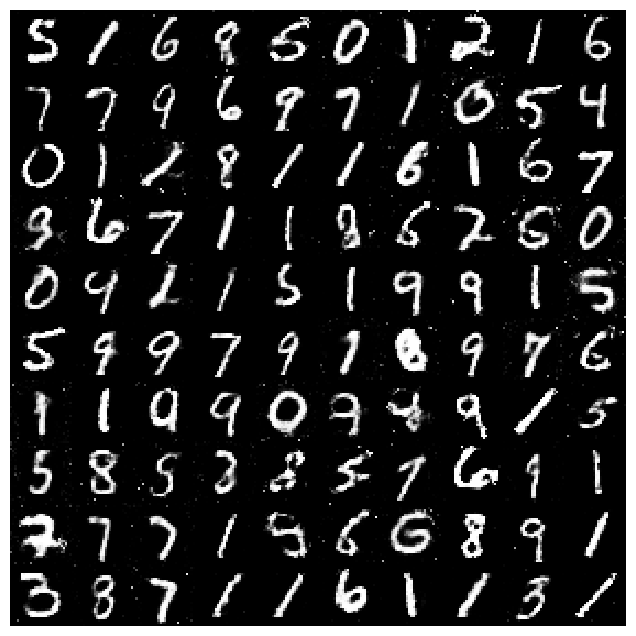

Epoch:   135
D Loss:  0.5843674540519714
G Loss:  0.9032683968544006
Epoch:   136
D Loss:  0.5857707858085632
G Loss:  0.9491399526596069


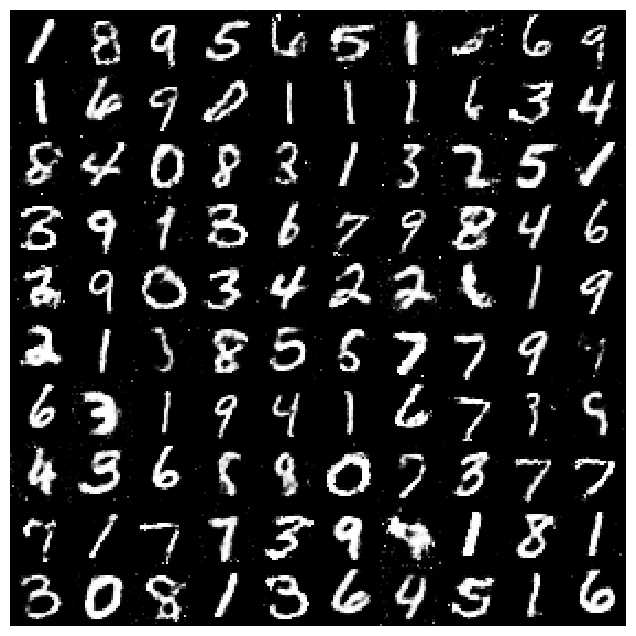

Epoch:   137
D Loss:  0.624108612537384
G Loss:  0.8006615042686462
Epoch:   138
D Loss:  0.5694646835327148
G Loss:  0.9486918449401855


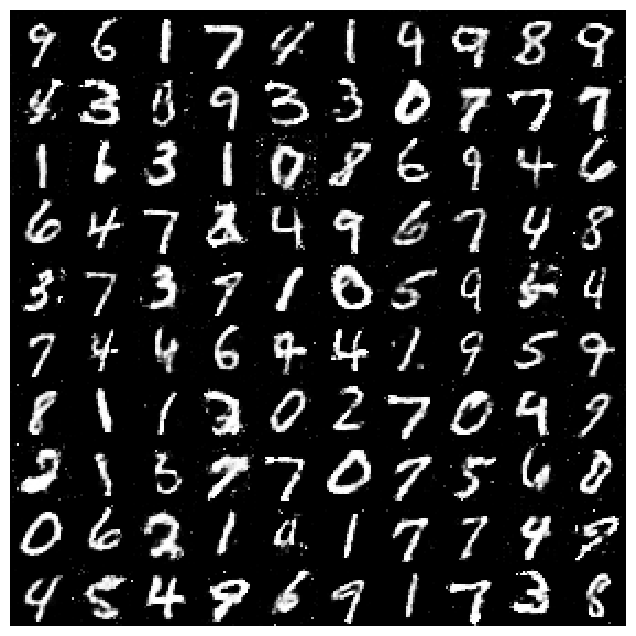

Epoch:   139
D Loss:  0.5968620777130127
G Loss:  1.031891942024231
Epoch:   140
D Loss:  0.5754752159118652
G Loss:  0.8841583132743835


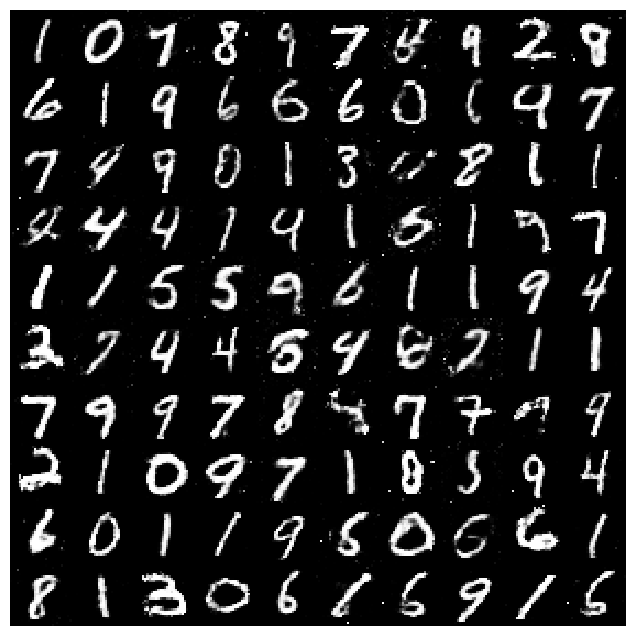

Epoch:   141
D Loss:  0.6154503226280212
G Loss:  1.0120081901550293
Epoch:   142
D Loss:  0.5805548429489136
G Loss:  0.9244750738143921


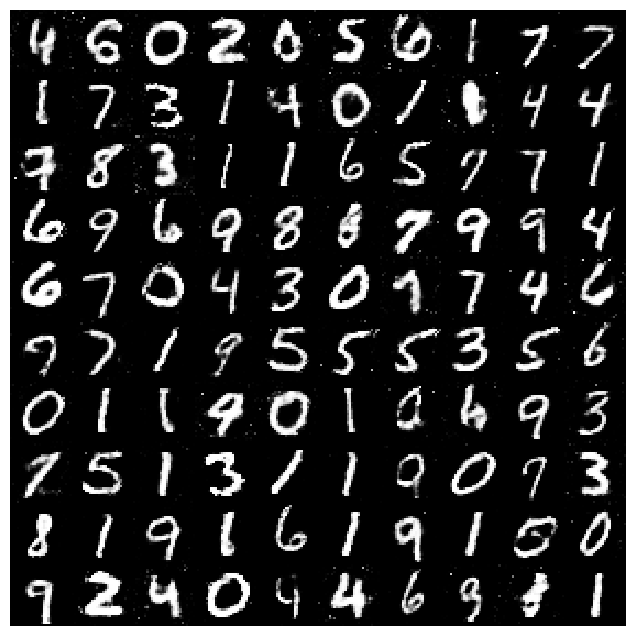

Epoch:   143
D Loss:  0.5588005781173706
G Loss:  1.007270097732544
Epoch:   144
D Loss:  0.5966282486915588
G Loss:  1.08487868309021


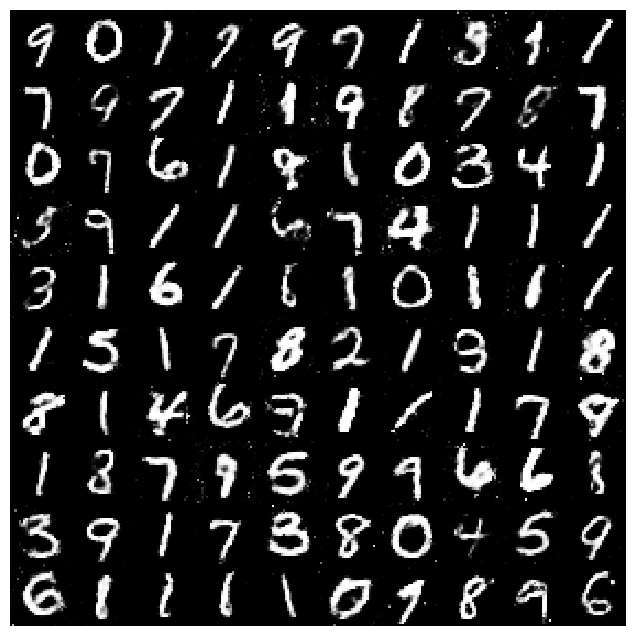

Epoch:   145
D Loss:  0.5554305911064148
G Loss:  1.2314205169677734
Epoch:   146
D Loss:  0.5793476104736328
G Loss:  1.0567309856414795


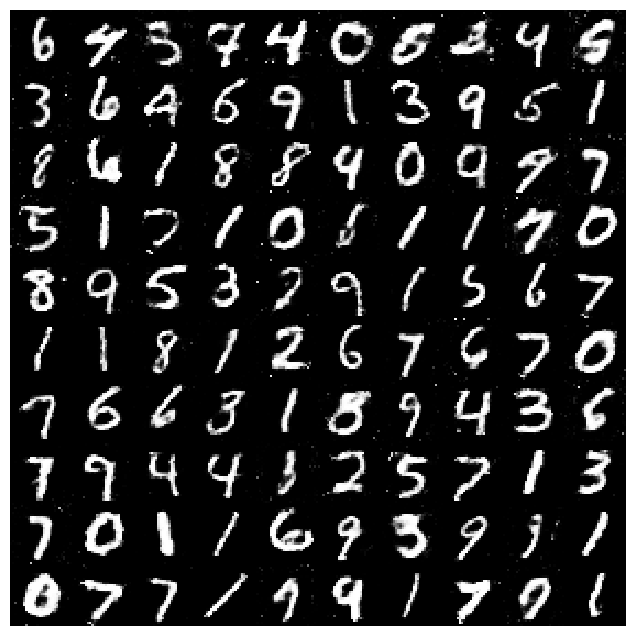

Epoch:   147
D Loss:  0.6194877028465271
G Loss:  1.007131814956665
Epoch:   148
D Loss:  0.5628241300582886
G Loss:  1.1265543699264526


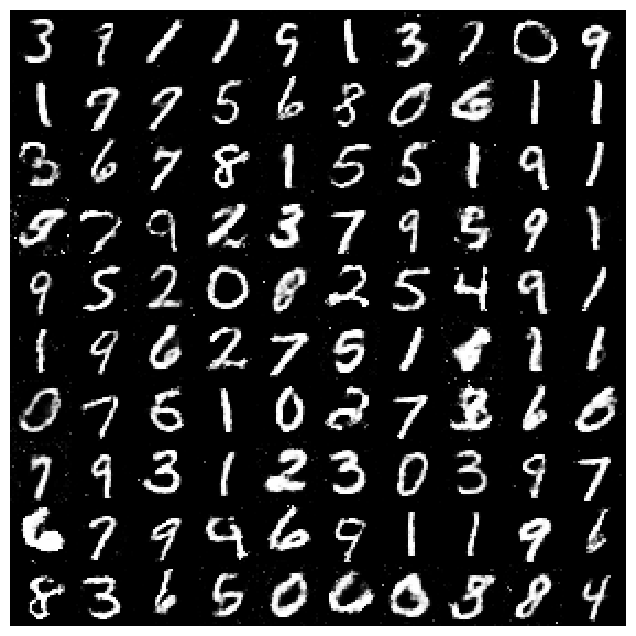

Epoch:   149
D Loss:  0.5509098768234253
G Loss:  0.985122799873352


In [14]:
## Training loop

for epoch in range(epochs):
    for i, (images, _) in enumerate(train_loader):
        
        # We set targets_real and targets_fake to non-binary values(soft and noisy labels).
        # This is a hack for stable training of GAN's.  
        # GAN hacks: https://github.com/soumith/ganhacks#6-use-soft-and-noisy-labels
        
        targets_real = (torch.FloatTensor(images.size(0), 1).uniform_(0.8, 1.0))
        targets_fake = (torch.FloatTensor(images.size(0), 1).uniform_(0.0, 0.2))
                
        if is_cuda:
            targets_real = targets_real.cuda()
            targets_fake = targets_fake.cuda()
            images = images.cuda()
        
        ## D-STEP:
        ## First, clear the gradients of the Discriminator optimizer.
        ## Estimate logits_real by passing images through the Discriminator
        ## Generate fake_images by passing random noise through the Generator. Also, .detach() the fake images 
        ## as we don't compute the gradients of the Generator when optimizing Discriminator.
        ## fake_images = generator(noise(train_bs, noise_dim)).detach()
        ## Estimate logits_fake by passing the fake images through the Discriminator
        ## Compute the Discriminator loss by calling DLoss function.
        ## Compute the gradients by backpropagating through the computational graph. 
        ## Update the Discriminator parameters.
        optimizer_D.zero_grad()
        logits_real = discriminator(images) 
        fake_images = generator(noise(train_bs, noise_dim)).detach()
        logits_fake= discriminator(fake_images)
        discriminator_loss = DLoss(logits_real, logits_fake, targets_real, targets_fake)
        discriminator_loss.backward()
        optimizer_D.step()
        
        ## G-STEP:
        ## clear the gradients of the Generator. 
        ## Generate fake images by passing random noise through the Generator. 
        ## Estimate logits_fake by passing the fake images through the Discriminator.
        ## compute the Generator loss by caling GLoss.
        ## compute the gradients by backpropagating through the computational graph.
        ## Update the Generator parameters. 
        
        # your code here
        optimizer_G.zero_grad()
        fake_images = generator(noise(train_bs, noise_dim))
        logits_fake = discriminator(fake_images)
        generator_loss= GLoss(logits_fake, targets_real)
        generator_loss.backward()
        optimizer_G.step()

    print("Epoch:  ", epoch)
    print("D Loss: ", discriminator_loss.item())
    print("G Loss: ", generator_loss.item())
          
    if epoch % 2 == 0:
        viz_batch = fake_images.data.cpu().numpy()
        viz_batch = viz_batch[:100,:,:,:]
        viz_batch = viz_batch.reshape(-1,28*28).squeeze()
        viz_batch = viz_batch.reshape(10,10, 28,28).transpose(0,2,1,3).reshape(28*10,-1)

        plt.figure(figsize = (8,8))
        plt.axis('off')
        plt.imshow(viz_batch, cmap='gray')
        plt.show()